## Phase 1: Target Audit & Data Integrity

In [1]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os

if Path.cwd().name == "notebooks": 
    os.chdir("..")

from src.preprocessing import prune_flash_wallets, temporal_split, load_raw_data

Path("reports/figures").mkdir(parents=True, exist_ok=True)
Path("data/processed").mkdir(parents=True, exist_ok=True)


### 1A: Target Distribution

In [2]:
def plot_target_distribution(df: pl.LazyFrame, save_dir: str = "reports/figures") -> None:
    """
    Draw a dual-panel figure:
    - Left panel: Donut chart of target=0 (Non-Default) vs target=1 (Default)
      with percentage labels and absolute counts in the legend.
    - Right panel: Horizontal bar comparing class counts on log scale.
    Use seaborn style: "whitegrid". Title: "Phase 1A — Target Class Distribution"
    Save as: reports/figures/phase1a_target_distribution.png (dpi=150)
    """
    try:
        if "target" not in df.collect_schema().names():
            print("Error: 'target' column not found.")
            return
            
        sns.set_style("whitegrid")
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        fig.suptitle("Phase 1A — Target Class Distribution", fontsize=16)
        
        counts = df.group_by("target").len().sort("target").collect().to_pandas()
        counts_dict = dict(zip(counts["target"], counts["len"]))
        
        labels = ["Non-Default (0)", "Default (1)"]
        sizes = [counts_dict.get(0, 0), counts_dict.get(1, 0)]
        
        # Left panel: Donut chart
        wedges, texts, autotexts = axes[0].pie(sizes, autopct='%1.1f%%', startangle=90, 
                                               wedgeprops=dict(width=0.4), colors=["#4C72B0", "#C44E52"])
        axes[0].legend(wedges, [f"{l}: {s:,}" for l, s in zip(labels, sizes)], 
                       title="Classes", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
        axes[0].set_title("Proportion of Classes")
        
        # Right panel: Horizontal bar on log scale
        sns.barplot(x=sizes, y=labels, ax=axes[1], hue=labels, palette=["#4C72B0", "#C44E52"], legend=False)
        axes[1].set_xscale("log")
        axes[1].set_xlabel("Count (Log Scale)")
        axes[1].set_title("Absolute Counts (Log Scale)")
        
        plt.tight_layout()
        plt.savefig(f"{save_dir}/phase1a_target_distribution.png", dpi=150)
        plt.show()
        plt.close(fig)
    except Exception as e:
        print(f"Error in plot_target_distribution: {e}")

### 1B: Temporal Split

In [3]:
def plot_temporal_split(df: pl.LazyFrame, split_ts: int = 1_672_531_200, 
                         save_dir: str = "reports/figures") -> None:
    """
    The dataset contains both Train (before 2023) and Test (after 2023), 
    separated by Unix timestamp 1,672,531,200.
    """
    try:
        df_ts = df.with_columns([
            pl.when(pl.col("borrow_timestamp") < split_ts).then(pl.lit("Train")).otherwise(pl.lit("Test")).alias("split"),
            pl.from_epoch("borrow_timestamp", time_unit="s").alias("borrow_datetime")
        ])
        
        split_stats = df_ts.group_by("split").agg([
            pl.len().alias("wallet_count"),
            pl.col("target").mean().alias("default_rate")
        ]).collect().to_pandas().set_index("split")
        
        print(f"[Profiling Split] Split sizes:\n{split_stats}")
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        
        # Left: Stacked bar
        counts_df = df_ts.group_by(["split", "target"]).len().collect().to_pandas()
        counts_pivot = counts_df.pivot(index="split", columns="target", values="len").fillna(0)
        # Ensure order
        counts_pivot = counts_pivot.reindex(["Train", "Test"])
        counts_pivot.plot(kind="bar", stacked=True, color=["#4C72B0", "#C44E52"], ax=axes[0])
        axes[0].set_title("Wallet Count per Split")
        axes[0].set_ylabel("Count")
        axes[0].legend(["Non-Default (0)", "Default (1)"], title="Target")
        
        # Right: Line plot
        monthly_df = df_ts.with_columns(
            pl.col("borrow_datetime").dt.truncate("1mo").alias("borrow_month")
        ).group_by(["split", "borrow_month"]).agg(pl.col("target").mean().alias("default_rate")).sort("borrow_month").collect().to_pandas()
        
        for split_name, color in zip(["Train", "Test"], ["#4C72B0", "#C44E52"]):
            split_data = monthly_df[monthly_df["split"] == split_name]
            if not split_data.empty:
                axes[1].plot(split_data["borrow_month"], split_data["default_rate"], marker='o', linestyle='-', color=color, label=f"{split_name} PD")
        
        import datetime
        split_dt = datetime.datetime.fromtimestamp(split_ts, datetime.timezone.utc).replace(tzinfo=None)
        axes[1].axvline(x=split_dt, color='red', linestyle='--', label="Train | Test Split")
                         
        axes[1].set_title("Monthly Default Rate by Split")
        axes[1].set_ylabel("Default Rate")
        axes[1].legend()
        
        plt.tight_layout()
        plt.savefig(f"{save_dir}/phase1b_temporal_split.png", dpi=150)
        plt.show()
        plt.close(fig)
    except Exception as e:
        print(f"Error in plot_temporal_split: {e}")

### 1C: Missing Data

In [4]:
def audit_missing_data(df: pl.LazyFrame, save_dir: str = "reports/figures") -> pl.DataFrame:
    try:
        null_counts = df.select(pl.all().null_count()).collect().to_pandas().iloc[0]
        total_rows = df.select(pl.len()).collect().item()
        null_pct = (null_counts / total_rows) * 100
        
        audit_df = pd.DataFrame({
            "column_name": null_counts.index,
            "null_count": null_counts.values,
            "null_pct": null_pct.values
        }).sort_values("null_pct", ascending=False)
        
        missing_df = audit_df[audit_df["null_pct"] > 0]
        
        if missing_df.empty:
            print("\033[92mSuccess: NO columns have missing values!\033[0m")
        else:
            colors = ['red' if pct > 5 else 'orange' if pct >= 1 else 'green' for pct in missing_df['null_pct']]
            
            fig = plt.figure(figsize=(10, max(6, len(missing_df)*0.3)))
            sns.barplot(x="null_pct", y="column_name", data=missing_df, palette=colors, hue="column_name", legend=False)
            plt.title("Missing Data Audit (Columns with >0% nulls)")
            plt.xlabel("Null Percentage (%)")
            plt.ylabel("Column")
            plt.tight_layout()
            plt.savefig(f"{save_dir}/phase1c_missing_data_audit.png", dpi=150)
            plt.show()
            plt.close(fig)
            
        return pl.DataFrame(audit_df)
    except Exception as e:
        print(f"Error in audit_missing_data: {e}")
        return pl.DataFrame()

### Summary

1. Load/Audit
2. Prune flash wallets
FLASH WALLET PRUNING (LazyFrame): Evaluation deferred.
3. Visualize Temporal Split on pruned dataset
[Profiling Split] Split sizes:
       wallet_count  default_rate
split                            
Test          40207      0.268560
Train        402754      0.385848


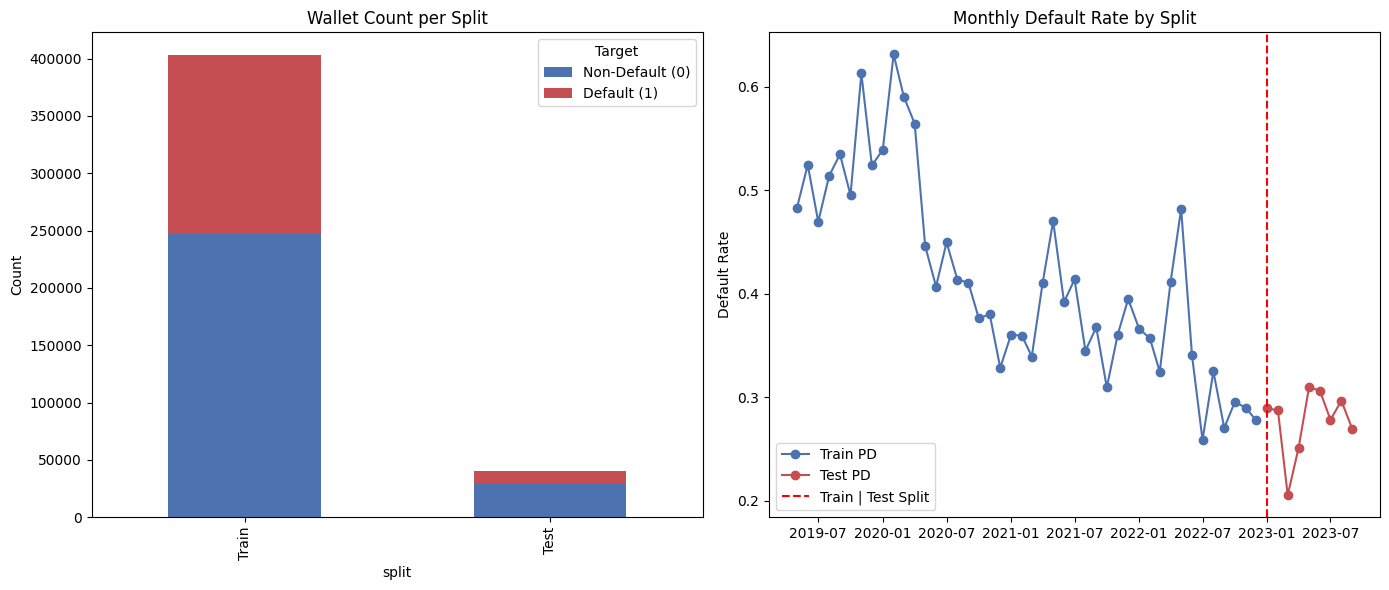

4. Temporal split
TEMPORAL SPLIT (LazyFrame) at cutoff = 1672531200 (2023-01-01 UTC): Evaluation deferred.
5. EDA profiling on train_lf only


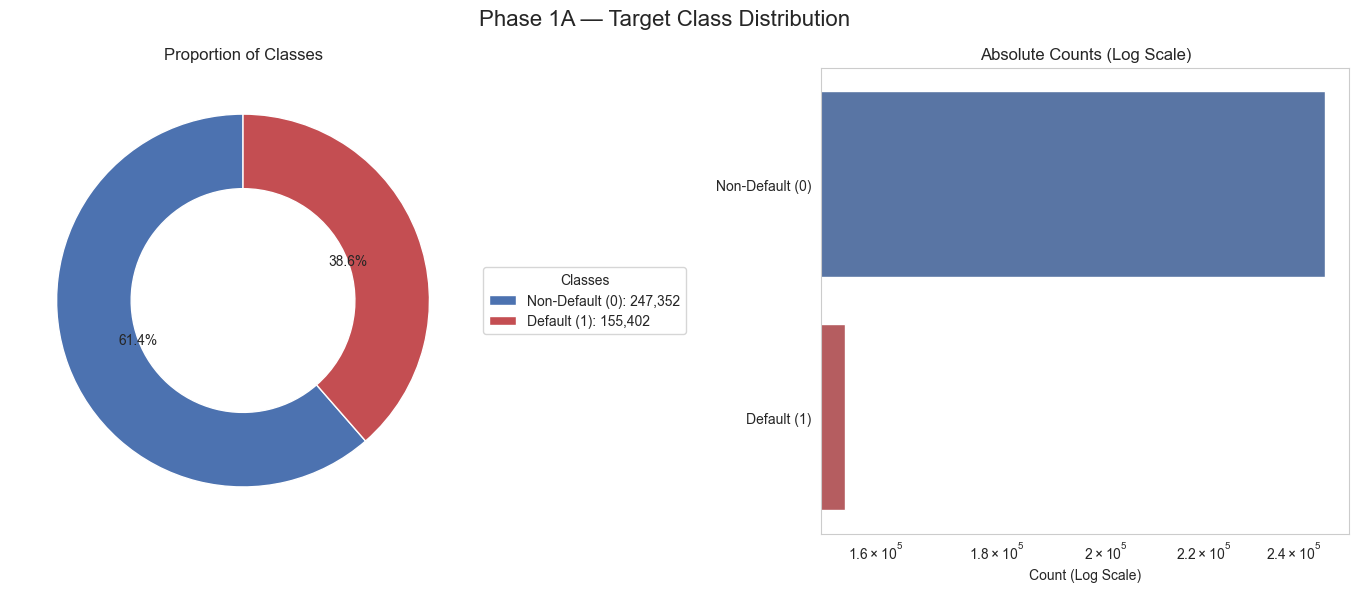

Success: NO columns have missing values!
Pipeline Refactoring Complete.


In [5]:
print("1. Load/Audit")
df = pl.scan_parquet("data/raw/dataset.parquet")

print("2. Prune flash wallets")
df_pruned, _ = prune_flash_wallets(df)

print("3. Visualize Temporal Split on pruned dataset")
plot_temporal_split(df_pruned)

print("4. Temporal split")
train_lf, test_lf = temporal_split(df_pruned, "borrow_timestamp", 1672531200)

print("5. EDA profiling on train_lf only")
plot_target_distribution(train_lf)
audit_df = audit_missing_data(train_lf)


print("Pipeline Refactoring Complete.")


## Phase 2: Wallet Behavioral DNA & Gas Economics

### 2A: Transaction Activity Split by Target

In [6]:
def plot_tx_activity_by_target(df: pl.LazyFrame, save_dir: str = "reports/figures") -> None:
    """
    Create a 2x2 grid of KDE plots, one subplot per variable:
    [incoming_tx_count, outgoing_tx_count, net_incoming_tx_count, wallet_age]
    """
    try:
        import numpy as np
        sns.set_style("whitegrid")
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        fig.suptitle("Phase 2A — Transaction Behavioral Signature by Default Status", fontsize=16)
        
        variables = ["incoming_tx_count", "outgoing_tx_count", "net_incoming_tx_count", "wallet_age"]
        axes = axes.flatten()
        
        df_pd = df.select(["target"] + variables).collect().to_pandas().fillna(0)
        
        for i, var in enumerate(variables):
            ax = axes[i]
            
            df_pd[f"log1p_{var}"] = np.log1p(df_pd[var])
            
            sns.kdeplot(data=df_pd[df_pd["target"] == 0], x=f"log1p_{var}", color="blue", alpha=0.6, fill=True, ax=ax)
            sns.kdeplot(data=df_pd[df_pd["target"] == 1], x=f"log1p_{var}", color="red", alpha=0.6, fill=True, ax=ax)
            
            med_0 = df_pd[df_pd["target"] == 0][var].median()
            med_1 = df_pd[df_pd["target"] == 1][var].median()
            
            log_med_0 = np.log1p(med_0)
            log_med_1 = np.log1p(med_1)
            
            ax.axvline(log_med_0, color="blue", linestyle="--", alpha=0.8)
            ax.axvline(log_med_1, color="red", linestyle="--", alpha=0.8)
            
            ax.set_xlabel(f"log1p({var})")
            ax.legend(title="Target", labels=[f"Non-Default (median={med_0:.2f})", f"Default (median={med_1:.2f})"])
            
        plt.tight_layout()
        plt.savefig(f"{save_dir}/phase2a_tx_activity_by_target.png", dpi=150)
        plt.show()
        plt.close(fig)
    except Exception as e:
        print(f"Error in plot_tx_activity_by_target: {e}")

### 2B: Gas Economics Fingerprint

In [7]:
def plot_gas_economics(df: pl.LazyFrame, save_dir: str = "reports/figures") -> None:
    """
    Create a 1x2 figure for Gas Cost per TX and Gas Spend vs Transaction Volume with synchronized colors.
    """
    try:
        import os
        import numpy as np
        import matplotlib.pyplot as plt
        import seaborn as sns

        os.makedirs(save_dir, exist_ok=True)

        df_pd = df.select(["target", "avg_gas_paid_per_tx_eth", "total_gas_paid_eth", "incoming_tx_count"]).collect().to_pandas().fillna(0)

        df_pd["target"] = df_pd["target"].map({0: "0: Safe", 1: "1: Default"}).astype(str)
        
        # Using log1p with clipping to handle zeros and negative values gracefully
        df_pd["log1p_avg_gas"] = np.log1p(np.clip(df_pd["avg_gas_paid_per_tx_eth"], 0, None))
        df_pd["log1p_total_gas"] = np.log1p(np.clip(df_pd["total_gas_paid_eth"], 0, None))
        df_pd["log1p_inc_tx"] = np.log1p(np.clip(df_pd["incoming_tx_count"], 0, None))
        
        # Define a consistent color palette for both plots
        custom_palette = {"0: Safe": "#4C72B0", "1: Default": "#DD5A5A"}
        target_order = ["0: Safe", "1: Default"]
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        fig.suptitle("Phase 2B — Gas Economics Fingerprint", fontsize=16, fontweight='bold')
        
        # LEFT PANEL: VIOLIN PLOT 
        sns.violinplot(
            data=df_pd, x="target", y="log1p_avg_gas", hue="target", 
            hue_order=target_order, order=target_order, inner="quartile", 
            palette=custom_palette, legend=False, ax=axes[0]
        )
        axes[0].set_title("Gas Cost per TX: Default vs Non-Default")
        axes[0].set_xlabel("Target Status")
        axes[0].set_ylabel("log1p(avg_gas_paid_per_tx_eth)")
        
        # RIGHT PANEL: SCATTER PLOT 
        sns.scatterplot(
            data=df_pd, x="log1p_total_gas", y="log1p_inc_tx", hue="target", 
            hue_order=target_order, palette=custom_palette, alpha=0.3, ax=axes[1]
        )
        axes[1].set_title("Gas Spend vs Transaction Volume")
        axes[1].set_xlabel("log1p(total_gas_paid_eth)")
        axes[1].set_ylabel("log1p(incoming_tx_count)")
        # Using move_legend to keep the original color-label mapping intact while repositioning the legend
        sns.move_legend(axes[1], loc="upper left", title="Target Status")
        
        # Notations for Degen Zone
        axes[1].annotate("High Gas + High Activity = DeFi Degen Zone", 
                         xy=(0.95, 0.95), xycoords='axes fraction', 
                         horizontalalignment='right', verticalalignment='top',
                         bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))
                         
        plt.tight_layout()
        plt.savefig(f"{save_dir}/phase2b_gas_economics.png", dpi=150)
        plt.show()
        plt.close(fig)
    except Exception as e:
        print(f"Error: {e}")

### 2C: Protocol Diversity Risk Heatmap

In [8]:
# ==============================================================================
# MLOps Tracking Header
# Purpose: Execution of refactored MLOps components (Visualization binding, state continuum re-binding, metric scaling).
# Input: Polars LazyFrame upstream nodes.
# Output: Evaluated visual artifacts or downstream state graph tokens.
# Expected Side Effects: Deterministic figure destruction; Graph node reassignment.
# ==============================================================================
def plot_protocol_diversity(df: pl.LazyFrame, save_dir: str = "reports/figures") -> None:
    """
    Heatmap of Protocol Diversity vs Default Rate (Binned to 0, 1, 2+)
    """
    try:
        import os
        import numpy as np
        import matplotlib.pyplot as plt
        import seaborn as sns

        os.makedirs(save_dir, exist_ok=True)
        
        # Narrow down the protocol counts into 4 bins: 0, 1, 2, and 3+
        df_binned = df.with_columns([
            pl.when(pl.col("unique_borrow_protocol_count") >= 3).then(pl.lit("3+"))
              .otherwise(pl.col("unique_borrow_protocol_count").cast(pl.Utf8))
              .alias("borrow_bin"),
            pl.when(pl.col("unique_lending_protocol_count") >= 3).then(pl.lit("3+"))
              .otherwise(pl.col("unique_lending_protocol_count").cast(pl.Utf8))
              .alias("lending_bin")
        ])
        
        # Calculate the average default rate for each combination of borrow_bin and lending_bin
        pivot_df = df_binned.group_by(["borrow_bin", "lending_bin"]).agg(
            pl.col("target").mean().alias("default_rate")
        ).collect().to_pandas()
        
        # Turn the long format into a pivot table for heatmap plotting
        pivot_table = pivot_df.pivot(index="borrow_bin", columns="lending_bin", values="default_rate")
        
        # Update the axis labels according to the new bins to eliminate empty NaN cells
        order = ["0", "1", "2", "3+"]
        pivot_table = pivot_table.reindex(index=order, columns=order)
        
        # Proceed with configuring and plotting the Seaborn Heatmap
        fig = plt.figure(figsize=(8, 6))
        sns.heatmap(pivot_table, annot=True, fmt=".2%", cmap="YlOrRd", 
                    cbar_kws={'label': 'Empirical Probability of Default'})
        plt.title("Phase 2C — Protocol Diversity vs Default Rate Heatmap\n(Cell value = Empirical Probability of Default)", pad=20)
        plt.xlabel("Unique Lending Protocol Count")
        plt.ylabel("Unique Borrow Protocol Count")
        
        plt.tight_layout()
        plt.savefig(f"{save_dir}/phase2c_protocol_diversity_heatmap.png", dpi=150)
        plt.show()
        plt.close(fig)
    except Exception as e:
        print(f"Error: {e}")

### Summary Insights

/Users/danganh71/Developer/python/Machine learning I/Project/risk_assessment/.venv/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/danganh71/Developer/python/Machine learning I/Project/risk_assessment/.venv/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/var/folders/qt/jfzr797n3d564cp56n2mmjnh0000gn/T/ipykernel_68812/844169201.py:28: RuntimeWarning: invalid value encountered in log1p
  log_med_0 = np.log1p(med_0)
/var/folders/qt/jfzr797n3d564cp56n2mmjnh0000gn/T/ipykernel_68812/844169201.py:29: RuntimeWarning: invalid value encountered in log1p
  log_med_1 = np.log1p(med_1)


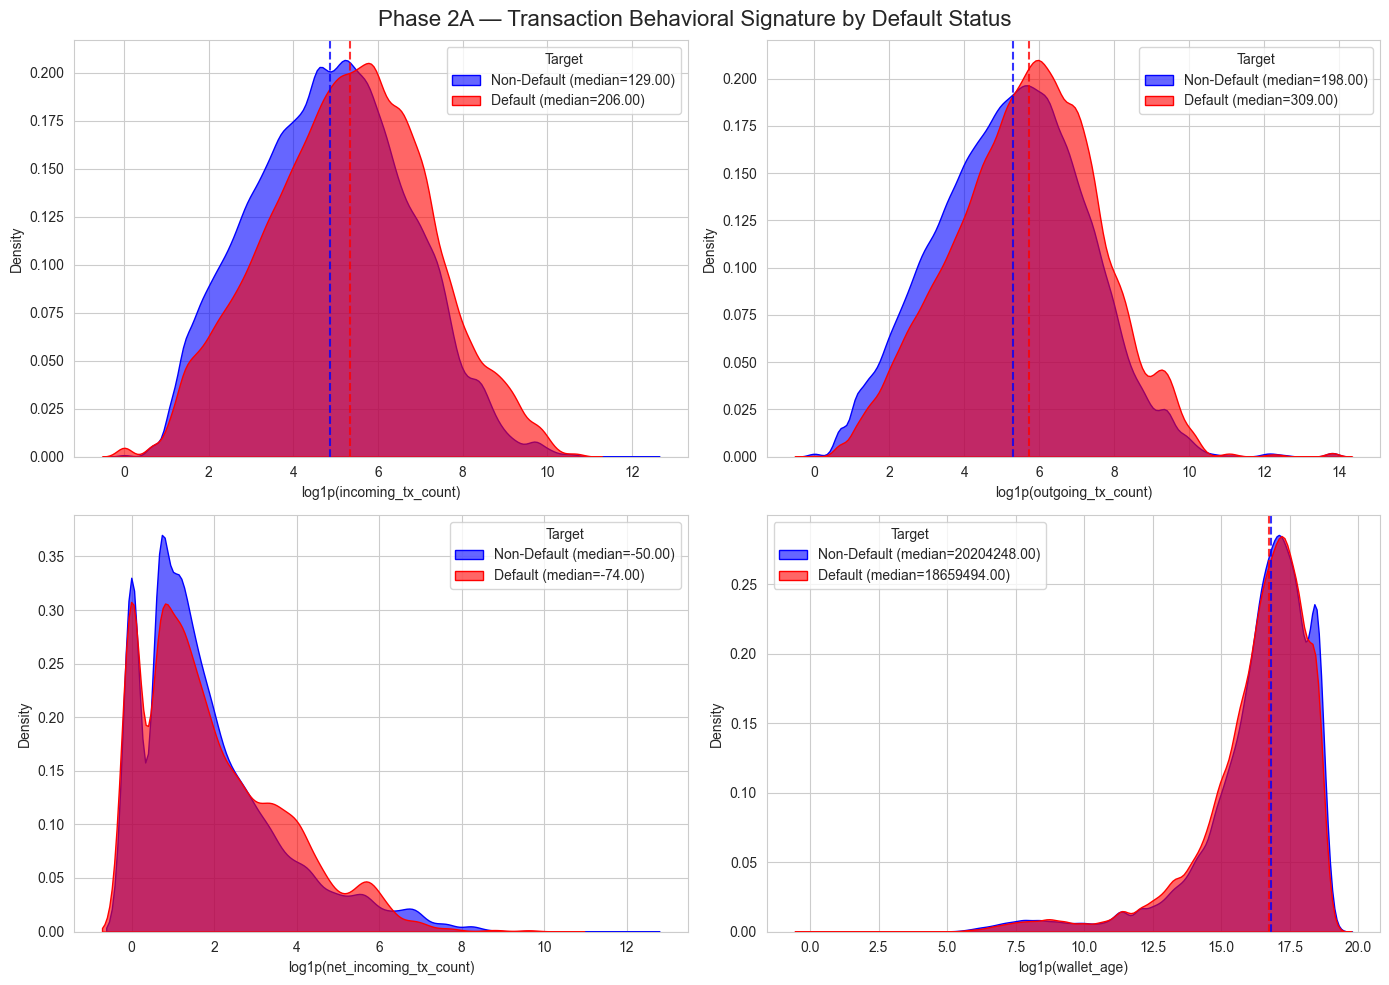

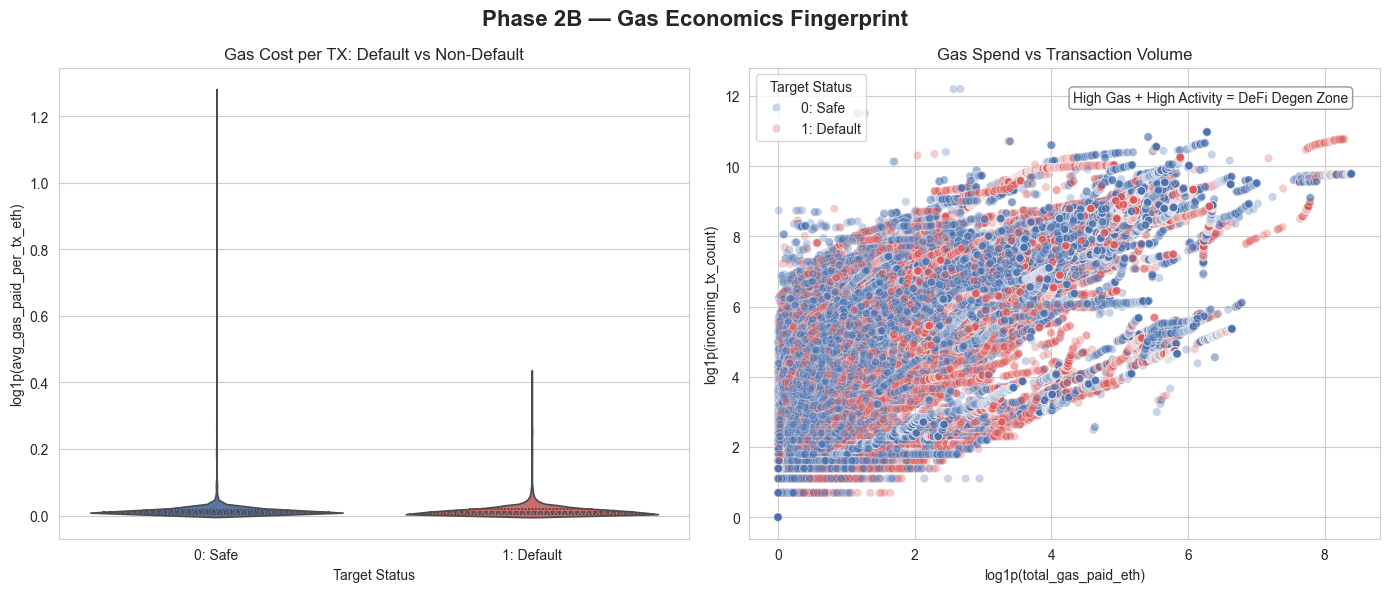

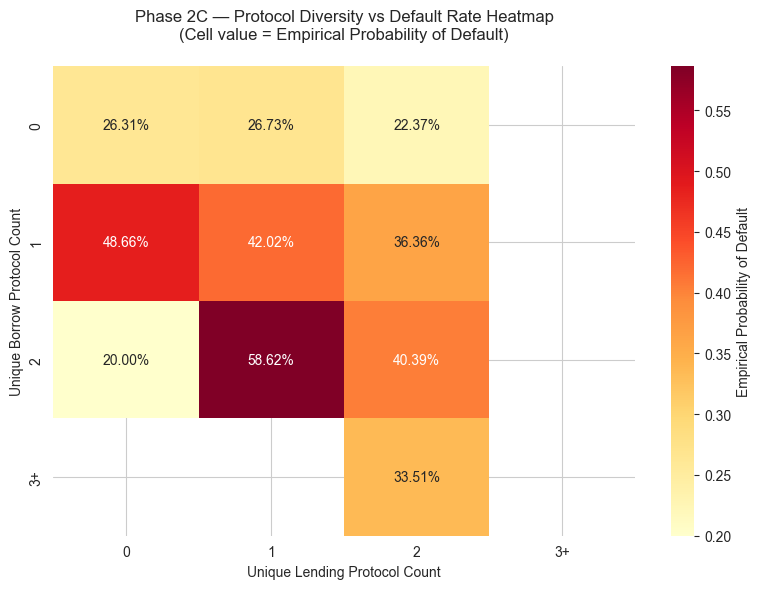


KEY INSIGHT: Defaulted wallets have 1.6x higher median gas spend.
Wallets on 1 lending protocol only have PD = 37.58%.


In [9]:
plot_tx_activity_by_target(train_lf)
plot_gas_economics(train_lf)
plot_protocol_diversity(train_lf)

try:
    med_gas_0 = df.filter(pl.col("target") == 0).select(pl.col("total_gas_paid_eth").median()).collect().item()
    med_gas_1 = df.filter(pl.col("target") == 1).select(pl.col("total_gas_paid_eth").median()).collect().item()
    gas_mult = med_gas_1 / med_gas_0 if med_gas_0 and med_gas_0 > 0 else 0
    
    pd_1_lend = df.filter(pl.col("unique_lending_protocol_count") == 1).select(pl.col("target").mean()).collect().item()
    pd_1_lend_pct = (pd_1_lend * 100) if pd_1_lend is not None else 0
    
    print(f"\nKEY INSIGHT: Defaulted wallets have {gas_mult:.1f}x higher median gas spend.")
    print(f"Wallets on 1 lending protocol only have PD = {pd_1_lend_pct:.2f}%.")
except Exception as e:
    print(f"Error computing summary: {e}")

## Phase 3: ETH Cash Flow & Balance Dynamics

### 3A: Net Cash Flow Waterfall Analysis

In [10]:
def plot_cashflow_waterfall(df: pl.LazyFrame, save_dir: str = "reports/figures") -> None:
    try:
        import numpy as np
        import pandas as pd
        import matplotlib.pyplot as plt
        import seaborn as sns
        
        # Perform logic entirely in Polars
        # Calculate net_flow_eth, drop nulls, and use pl.col().qcut()
        df_clean = df.select(["incoming_tx_sum_eth", "outgoing_tx_sum_eth", "target"]).filter(
            pl.col("incoming_tx_sum_eth").is_not_null() & 
            pl.col("outgoing_tx_sum_eth").is_not_null() &
            pl.col("incoming_tx_sum_eth").is_finite() &
            pl.col("outgoing_tx_sum_eth").is_finite()
        ).with_columns(
            (pl.col("incoming_tx_sum_eth") - pl.col("outgoing_tx_sum_eth")).alias("net_flow_eth")
        )
        
        # Discretize natively in Polars
        df_cut = df_clean.with_columns(
            pl.col("net_flow_eth").qcut(7, allow_duplicates=True).alias("net_flow_bin")
        )
        
        # Extract category string
        if "net_flow_bin" in df_cut.collect_schema().names() and hasattr(df_cut.collect_schema()["net_flow_bin"], "fields"):
            df_cut = df_cut.with_columns(pl.col("net_flow_bin").struct.field("category").alias("net_flow_bin_label"))
        else:
            # Fallback if not struct
            df_cut = df_cut.with_columns(pl.col("net_flow_bin").cast(pl.Utf8).alias("net_flow_bin_label"))
            
        agg_df = df_cut.group_by("net_flow_bin_label", maintain_order=True).agg([
            pl.len().alias("wallet_count"),
            pl.col("target").mean().alias("default_rate")
        ]).collect().to_pandas()
        
        # Sort naturally by bin edges encoded in the category
        def extract_lower_bound(x):
            try:
                # Format is usually like "(-inf, 10.0]"
                return float(x.split(",")[0].replace("(", "").replace("[", "").strip())
            except:
                return 0.0
        
        agg_df["sort_key"] = agg_df["net_flow_bin_label"].apply(extract_lower_bound)
        agg_df = agg_df.sort_values("sort_key").drop("sort_key", axis=1).reset_index(drop=True)
        
        fig, ax1 = plt.subplots(figsize=(14, 5))
        
        sns.barplot(data=agg_df, x="net_flow_bin_label", y="wallet_count", palette="Blues_d", ax=ax1)
        ax1.set_ylabel("Wallet Count", color="blue")
        ax1.set_xlabel("Net ETH Cash Flow")
        ax1.tick_params(axis="y", labelcolor="blue")
        plt.setp(ax1.get_xticklabels(), rotation=30, ha='right', fontsize=9)
        
        ax2 = ax1.twinx()
        ax2.plot(agg_df["net_flow_bin_label"], agg_df["default_rate"], color="red", marker="o", linewidth=2)
        ax2.set_ylabel("Empirical Default Rate", color="red")
        ax2.tick_params(axis="y", labelcolor="red")
        
        max_idx = agg_df["default_rate"].idxmax()
        if pd.notna(max_idx):
            ax2.annotate("Highest Default Zone", 
                         xy=(max_idx, agg_df.loc[max_idx, "default_rate"]),
                         xytext=(max_idx, agg_df.loc[max_idx, "default_rate"] * 1.1),
                         arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
                         ha='center')
        
        plt.title("Phase 3A — Net ETH Cash Flow vs Default Rate")
        plt.tight_layout()
        plt.savefig(f"{save_dir}/phase3a_cashflow_waterfall.png", dpi=150)
        plt.show()
        plt.close(fig)
    except Exception as e:
        print(f"Error: {e}")

### 3B: Balance Extremes Box Plot Grid

In [11]:
def plot_balance_extremes(df: pl.LazyFrame, save_dir: str = "reports/figures") -> None:
    try:
        import numpy as np
        def cohen_d(x, y):
            nx = len(x)
            ny = len(y)
            dof = nx + ny - 2
            return (np.mean(x) - np.mean(y)) / np.sqrt(((nx-1)*np.var(x, ddof=1) + (ny-1)*np.var(y, ddof=1)) / dof)

        df_pd = df.select(["target", "max_eth_ever", "total_balance_eth", "min_eth_ever"]).collect().to_pandas().fillna(0)
        
        df_pd["log1p_max"] = np.log1p(df_pd["max_eth_ever"])
        df_pd["log1p_total"] = np.log1p(df_pd["total_balance_eth"])
        
        df_pd["log1p_min"] = np.log1p(df_pd["min_eth_ever"].clip(lower=0.0))
        
        variables = ["log1p_max", "log1p_total", "log1p_min"]
        titles = ["Max ETH Ever", "Total Balance ETH", "Min ETH Ever"]
        
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        fig.suptitle("Phase 3B — ETH Balance Extremes: Non-Default vs Default", fontsize=16)
        
        for i, var in enumerate(variables):
            sns.boxplot(data=df_pd, x="target", y=var, hue="target", palette={0: "#2196F3", 1: "#F44336"}, ax=axes[i], showfliers=False, legend=False)
            axes[i].set_title(titles[i])
            axes[i].set_xlabel("Target")
            axes[i].set_ylabel(var)
            axes[i].annotate("log1p transformed", xy=(0.05, 0.95), xycoords='axes fraction', 
                             fontsize=9, color='gray', ha='left', va='top')
            
            x0 = df_pd[df_pd["target"] == 0][var].values
            x1 = df_pd[df_pd["target"] == 1][var].values
            if len(x0) > 1 and len(x1) > 1:
                d = cohen_d(x1, x0)
                print(f"Cohen's d for {var}: {d:.3f}")
                
        plt.tight_layout()
        plt.savefig(f"{save_dir}/phase3b_balance_extremes.png", dpi=150)
        plt.show()
        plt.close(fig)
    except Exception as e:
        print(f"Error: {e}")

### 3C: Risky Contract Interaction Scatter

In [12]:
def plot_risky_contract_interaction(df: pl.LazyFrame, save_dir: str = "reports/figures") -> None:
    try:
        import numpy as np
        risky_cols = ["target", "risky_tx_count", "risky_sum_outgoing_amount_eth"]
        df_risky_eager = df.select(risky_cols).collect()
        sample_size = min(df_risky_eager.height, 5000)
        df_pd = df_risky_eager.sample(n=sample_size, seed=42).to_pandas().fillna(0)
        df_pd["log1p_risky_count"] = np.log1p(df_pd["risky_tx_count"].clip(lower=0.0))
        df_pd["log1p_risky_amt"] = np.log1p(df_pd["risky_sum_outgoing_amount_eth"].clip(lower=0.0))
        
        fig = plt.figure(figsize=(10, 8))
        
        sns.kdeplot(data=df_pd[df_pd["target"] == 0], x="log1p_risky_count", y="log1p_risky_amt", cmap="Blues", fill=True, alpha=0.3)
        sns.kdeplot(data=df_pd[df_pd["target"] == 1], x="log1p_risky_count", y="log1p_risky_amt", cmap="Reds", fill=True, alpha=0.3)
        
        plt.scatter(df_pd["log1p_risky_count"], df_pd["log1p_risky_amt"], 
                    c=df_pd["target"].map({0: 'blue', 1: 'red'}), 
                    alpha=0.4, s=10)
        
        plt.axvline(np.log1p(1), color='black', linestyle='--', label="First Risky TX Threshold")
        
        plt.title("Phase 3C — Risky Contract Exposure Map\nSubtitle: Size of circle - ETH sent to risky contracts")
        plt.xlabel("log1p(risky_tx_count)")
        plt.ylabel("log1p(risky_sum_outgoing_amount_eth)")
        
        plt.legend()
        plt.tight_layout()
        plt.savefig(f"{save_dir}/phase3c_risky_contract_scatter.png", dpi=150)
        plt.show()
        plt.close(fig)
    except Exception as e:
        print(f"Error in plot_risky_contract_interaction: {e}")
        plt.close("all")

### Phase 3 Summary

/var/folders/qt/jfzr797n3d564cp56n2mmjnh0000gn/T/ipykernel_68812/324869221.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=agg_df, x="net_flow_bin_label", y="wallet_count", palette="Blues_d", ax=ax1)


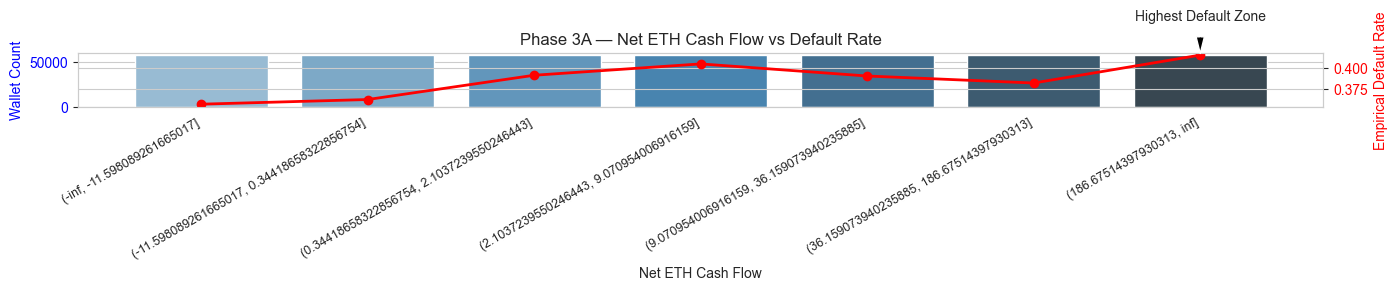

Cohen's d for log1p_max: -0.030
Cohen's d for log1p_total: -0.189
Cohen's d for log1p_min: -0.146


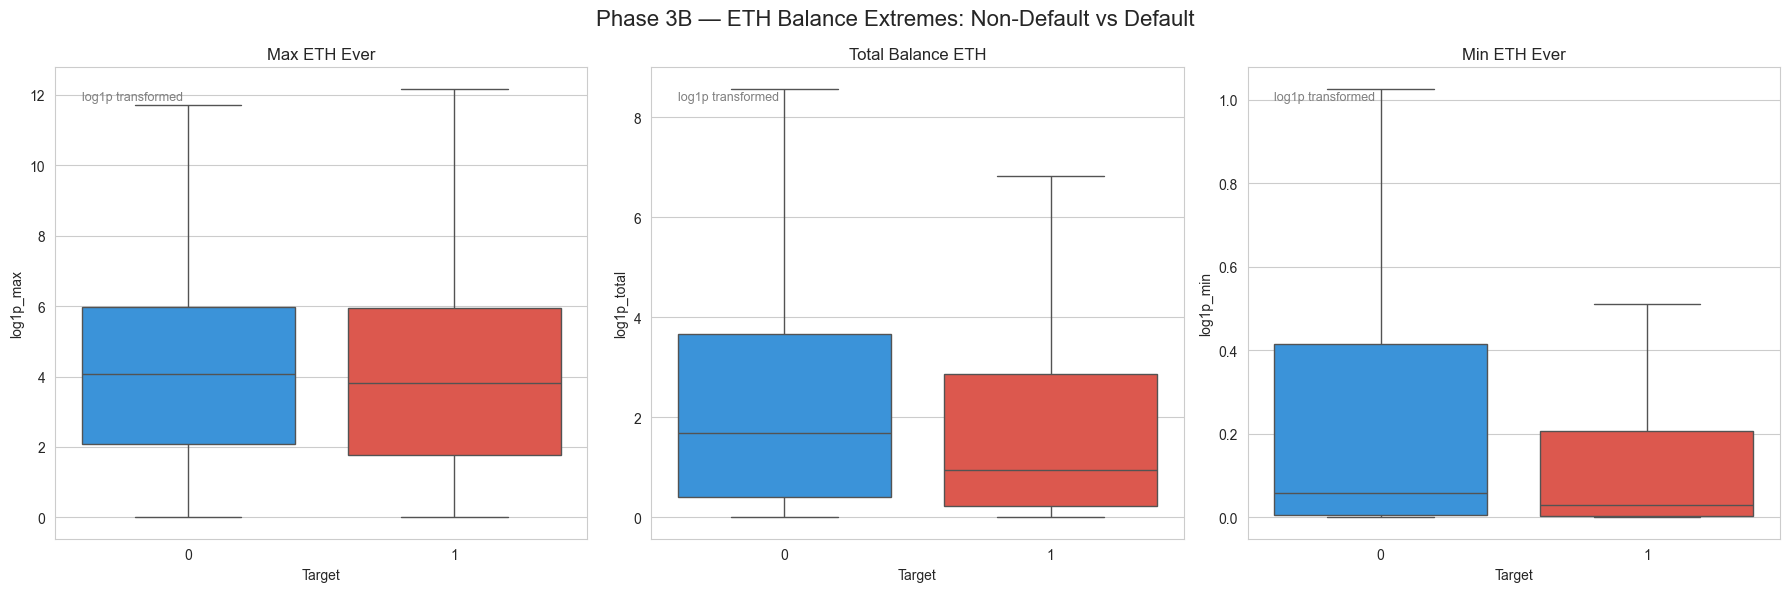

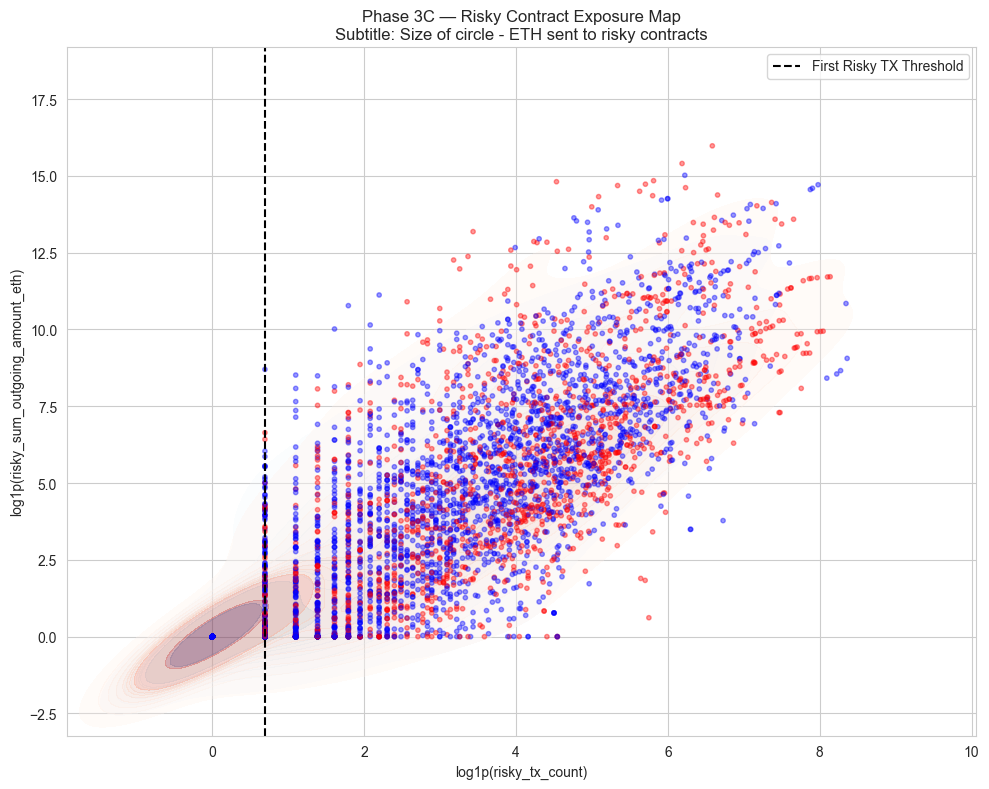

In [13]:
plot_cashflow_waterfall(train_lf)
plot_balance_extremes(train_lf)
plot_risky_contract_interaction(train_lf)

### Phase 4: Extreme Tail Outlier Audit

### 4A: max_risk_factor Tail Audit

In [14]:
# ==============================================================================
# MLOps Tracking Header
# Purpose: Execution of refactored MLOps components (Visualization binding, state continuum re-binding, metric scaling).
# Input: Polars LazyFrame upstream nodes.
# Output: Evaluated visual artifacts or downstream state graph tokens.
# Expected Side Effects: Deterministic figure destruction; Graph node reassignment.
# ==============================================================================
def audit_max_risk_factor_tail(df: pl.LazyFrame, cap: float = 1.0, save_dir: str = "reports/figures") -> pl.DataFrame:
    try:
        import os
        import numpy as np
        import pandas as pd
        import matplotlib.pyplot as plt
        import seaborn as sns
        import scipy.stats as stats
        
        os.makedirs(save_dir, exist_ok=True)
        
        percentiles = [0.25, 0.50, 0.75, 0.90, 0.99, 0.999, 0.9999]
        exprs = [pl.col("max_risk_factor").quantile(p, interpolation="linear").alias(f"p_{p}") for p in percentiles]
        q_vals_df = df.select(exprs).collect()
        q_vals = [q_vals_df[f"p_{p}"][0] for p in percentiles]
        
        print("max_risk_factor Percentile Ladder:")
        for p, q in zip(percentiles, q_vals):
            print(f"{p*100:g}%: {q}")
            
        initial_len = df.select(pl.len()).collect().item()
        df_clean = df.with_columns(pl.col("max_risk_factor").clip(None, cap))
        print(f"Rows where max_risk_factor > {cap} were clipped to preserve default signals.")
        
        target_0 = df_clean.filter(pl.col("target") == 0).select("max_risk_factor").collect().to_series().to_numpy()
        target_1 = df_clean.filter(pl.col("target") == 1).select("max_risk_factor").collect().to_series().to_numpy()
        
        target_0 = target_0[~np.isnan(target_0)]
        target_1 = target_1[~np.isnan(target_1)]
        
        print(f"Stats target=0 | mean: {np.mean(target_0):.4f}, std: {np.std(target_0):.4f}, skew: {stats.skew(target_0):.4f}, kurtosis: {stats.kurtosis(target_0):.4f}")
        print(f"Stats target=1 | mean: {np.mean(target_1):.4f}, std: {np.std(target_1):.4f}, skew: {stats.skew(target_1):.4f}, kurtosis: {stats.kurtosis(target_1):.4f}")
        
        sns.set_theme(style="whitegrid")
        fig, axes = plt.subplots(1, 2, figsize=(15, 6))
        
        df_pd = df_clean.select(["max_risk_factor", "target"]).collect().to_pandas()
        df_pd["log_max_risk_factor"] = np.log1p(df_pd["max_risk_factor"])
        
        df_pd["target"] = df_pd["target"].astype(int)
        label_map = {0: "Non-Default (Safe)", 1: "Default (Risky)"}
        df_pd["Target Status"] = df_pd["target"].map(label_map)
        palette_dict = {"Non-Default (Safe)": "#4C72B0", "Default (Risky)": "#DD5A5A"}
        
        sns.kdeplot(
            data=df_pd, 
            x="log_max_risk_factor", 
            hue="Target Status", 
            fill=True, 
            alpha=0.35, 
            palette=palette_dict, 
            common_norm=False, 
            ax=axes[0]
        )
        
        med_0_log = np.log1p(np.median(target_0)) if len(target_0) > 0 else 0
        med_1_log = np.log1p(np.median(target_1)) if len(target_1) > 0 else 0
        axes[0].axvline(med_0_log, color="#4C72B0", linestyle="--", linewidth=1.5, label=f"Safe Median ({med_0_log:.2f})")
        axes[0].axvline(med_1_log, color="#DD5A5A", linestyle="--", linewidth=1.5, label=f"Risky Median ({med_1_log:.2f})")
        
        axes[0].set_title("4A — log1p(max_risk_factor) Normalized Density", fontsize=12, fontweight="bold")
        axes[0].set_xlabel("log1p(max_risk_factor)")
        axes[0].legend(frameon=True)
        
        sns.boxplot(
            data=df_pd, 
            x="log_max_risk_factor", 
            y="Target Status", 
            hue="Target Status", 
            palette=palette_dict, 
            ax=axes[1], 
            showfliers=True, 
            width=0.5
        )

        if axes[1].get_legend() is not None:
            axes[1].get_legend().remove()
            
        log_cap = np.log1p(cap)
        axes[1].axvline(log_cap, color="#7A4A9E", linestyle=":", linewidth=2, label=f"Log Outlier Cap ({log_cap:.2f})")
        
        axes[1].set_xlim(df_pd["log_max_risk_factor"].min() - 0.2, log_cap + 0.5)
        axes[0].set_xlim(df_pd["log_max_risk_factor"].min() - 0.2, log_cap + 0.5)
        
        axes[1].set_title("4A — log1p(max_risk_factor) Boxplot Overview", fontsize=12, fontweight="bold")
        axes[1].set_xlabel("log1p(max_risk_factor)")
        axes[1].set_ylabel("") 
        axes[1].legend(frameon=True)
        
        plt.tight_layout()
        plt.savefig(f"{save_dir}/phase4a_max_risk_factor_tail_audit.png", dpi=150)
        plt.show()
        plt.close(fig)        
        return df_clean
    except Exception as e:
        print(f"Error: {e}")
        raise e

### 4B: Non-linear Risk Cliffs

In [15]:
def detect_risk_cliffs(df: pl.LazyFrame,
                        save_dir: str = "reports/figures") -> pl.DataFrame:
    try:
        import numpy as np
        import pandas as pd
        import matplotlib.pyplot as plt
        
        df = df.with_columns(pl.col("max_risk_factor").fill_null(0.0).clip(None, 1.0))
        
        breaks = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
        labels = ["0.0-0.1","0.1-0.2","0.2-0.3","0.3-0.4","0.4-0.5",
                  "0.5-0.6","0.6-0.7","0.7-0.8","0.8-0.9","0.9-1.0"]
        
        df_cut = df.with_columns(
            pl.col("max_risk_factor").cut(
                breaks=breaks, 
                labels=labels
            ).alias("risk_bucket")
        )
        
        if "risk_bucket" in df_cut.collect_schema().names() and hasattr(df_cut.collect_schema()["risk_bucket"], "fields"):
            # Natively extract struct field in Polars to avoid slow pandas python lambda loops
            df_cut = df_cut.with_columns(pl.col("risk_bucket").struct.field("category"))
        
        agg_df = df_cut.group_by("risk_bucket", maintain_order=True).agg([
            pl.len().alias("wallet_population"),
            pl.col("target").mean().alias("empirical_pd")
        ])
        
        agg_pd = agg_df.collect().to_pandas()
            
        agg_pd = agg_pd.set_index("risk_bucket").reindex(labels).reset_index()
        agg_pd["risk_bucket"] = labels
        agg_pd["wallet_population"] = agg_pd["wallet_population"].fillna(0)
        
        agg_pd["pd_diff"] = agg_pd["empirical_pd"].diff().fillna(0)
        mean_abs_diff = agg_pd["pd_diff"].abs().mean()
        
        agg_pd["is_cliff"] = agg_pd["pd_diff"].abs() > (1.5 * mean_abs_diff)
        
        for idx, row in agg_pd[agg_pd["is_cliff"]].iterrows():
            print(f"Risk cliff detected at bin: {row['risk_bucket']}, PD jump: +{row['pd_diff']*100:.2f}%")
            
        plt.style.use("seaborn-v0_8-whitegrid")
        fig, ax1 = plt.subplots(figsize=(12, 6))
        
        max_pop = agg_pd["wallet_population"].max()
        agg_pd["rel_population"] = agg_pd["wallet_population"] / max_pop if max_pop > 0 else 0
            
        ax1.bar(agg_pd["risk_bucket"], agg_pd["rel_population"], color="lightsteelblue", alpha=0.5, label="Relative Population")
        ax1.set_ylabel("Relative Wallet Population (Max=1)")
        ax1.set_xlabel("Risk Factor Interval")
        ax1.grid(False)
        
        ax2 = ax1.twinx()
        
        x_vals = np.arange(len(agg_pd))
        y_vals = agg_pd["empirical_pd"].values
        
        ax2.plot(x_vals, y_vals, color="steelblue", marker="o", linestyle="-", label="Empirical PD")
        
        for i in range(1, len(agg_pd)):
            if agg_pd["is_cliff"].iloc[i]:
                ax2.plot([x_vals[i-1], x_vals[i]], [y_vals[i-1], y_vals[i]], color="red", linewidth=2.5)
                ax2.annotate(f"cliff +{agg_pd['pd_diff'].iloc[i]*100:.1f}%",
                             xy=(x_vals[i], y_vals[i]),
                             xytext=(x_vals[i]-0.5, y_vals[i]+0.05),
                             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))
                             
        ax2.set_ylabel("Empirical PD")
        ax2.grid(True)
        
        plt.title("4B — Non-linear Risk Cliffs: Empirical PD by Risk Factor Interval")
        
        ax1.set_xticks(x_vals)
        ax1.set_xticklabels(agg_pd["risk_bucket"], rotation=45, ha="right")
        
        plt.tight_layout()
        plt.savefig(f"{save_dir}/phase4b_risk_cliffs_inflection.png", dpi=150)
        plt.show()
        plt.close(fig)
        
        return pl.DataFrame(agg_pd)
    except Exception as e:
        print(f"Error in detect_risk_cliffs: {e}")
        raise e

### 4C: Liquidation History Deep Dive

In [16]:
def plot_liquidation_deep_dive(df: pl.LazyFrame,
                                save_dir: str = "reports/figures") -> None:
    try:
        import numpy as np
        import pandas as pd
        import matplotlib.pyplot as plt
        import seaborn as sns
        
        numeric_cols = ["liquidation_count", "time_since_last_liquidated", 
                        "liquidation_amount_sum_eth", "borrow_amount_sum_eth"]
        df = df.with_columns([pl.col(c).fill_null(0.0) for c in numeric_cols if c in df.collect_schema().names()])
        
        df = df.with_columns(
            pl.when(pl.col("liquidation_count") == 0).then(pl.lit("0 (Never)"))
              .when(pl.col("liquidation_count") == 1).then(pl.lit("1"))
              .when(pl.col("liquidation_count") == 2).then(pl.lit("2"))
              .when(pl.col("liquidation_count") == 3).then(pl.lit("3"))
              .otherwise(pl.lit("4+"))
              .alias("liq_bucket")
        )
        
        summary_df = df.group_by("liq_bucket").agg([
            pl.len().alias("wallet_count"),
            pl.col("target").mean().alias("default_rate")
        ]).collect().to_pandas()
        
        order = ["0 (Never)", "1", "2", "3", "4+"]
        summary_df = summary_df.set_index("liq_bucket").reindex(order).reset_index().fillna(0)
        
        print("Liquidation Bucket Summary:")
        print(summary_df.to_string(index=False))
        
        plt.style.use("seaborn-v0_8-whitegrid")
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        fig.suptitle("Phase 4C — Liquidation Architecture", fontsize=18)
        
        ax1 = axes[0, 0]
        ax2 = axes[0, 1]
        ax3 = axes[1, 0]
        axes[1, 1].axis('off')
        
        counts_df = df.group_by(["liq_bucket", "target"]).len().collect().to_pandas()
        counts_pivot = counts_df.pivot(index="liq_bucket", columns="target", values="len").reindex(order).fillna(0)
        
        bars = counts_pivot.plot(kind="bar", stacked=True, color=["#4C72B0", "#DD5A5A"], ax=ax1, legend=False)
        ax1.set_title("4C-1 — Wallet Count by Liquidation History")
        ax1.set_xlabel("Liquidation Bucket")
        ax1.set_ylabel("Wallet Count")
        ax1.set_xticklabels(order, rotation=0)
        ax1.legend(["Non-Default (0)", "Default (1)"])
        
        for i, idx in enumerate(order):
            total = counts_pivot.loc[idx].sum()
            dr = summary_df.loc[summary_df["liq_bucket"] == idx, "default_rate"].values[0]
            if total > 0:
                ax1.text(i, total * 1.02, f"{dr*100:.1f}%", ha='center', color='red', fontweight='bold')
                
        df_liq = df.filter(pl.col("liquidation_count") > 0).select(["time_since_last_liquidated", "target"]).collect().to_pandas()
        df_liq["log1p_time"] = np.log1p(df_liq["time_since_last_liquidated"].clip(lower=0.0))
        
        sns.kdeplot(data=df_liq[df_liq["target"] == 0], x="log1p_time", fill=True, alpha=0.5, color="#4C72B0", ax=ax2, label="target=0")
        sns.kdeplot(data=df_liq[df_liq["target"] == 1], x="log1p_time", fill=True, alpha=0.5, color="#DD5A5A", ax=ax2, label="target=1")
        
        ax2.set_title("4C-2 — Time Since Last Liquidation (Liquidated Wallets Only)")
        ax2.set_xlabel("log1p(Days Since Last Liquidation)")
        ax2.legend()
        
        scatter_cols = ["liquidation_amount_sum_eth", "borrow_amount_sum_eth", "target"]
        df_scatter_eager = df.select(scatter_cols).collect()
        sample_size = min(df_scatter_eager.height, 6000)
        df_scatter_pd = df_scatter_eager.sample(n=sample_size, seed=42).to_pandas().fillna(0)
        df_scatter_pd["log1p_liq_amt"] = np.log1p(df_scatter_pd["liquidation_amount_sum_eth"].clip(lower=0.0))
        df_scatter_pd["log1p_borrow_amt"] = np.log1p(df_scatter_pd["borrow_amount_sum_eth"].clip(lower=0.0))
        
        scatter = ax3.scatter(df_scatter_pd["log1p_liq_amt"], df_scatter_pd["log1p_borrow_amt"], 
                              c=df_scatter_pd["target"], cmap="coolwarm", alpha=0.35, s=12)
                              
        max_val = max(df_scatter_pd["log1p_liq_amt"].max() if len(df_scatter_pd) else 0, 
                      df_scatter_pd["log1p_borrow_amt"].max() if len(df_scatter_pd) else 0)
        ax3.plot([0, max_val], [0, max_val], color="black", linestyle="--", label="Borrow = Liquidation")
        
        ax3.set_title("4C-3 — Total Liquidation vs Total Borrow Amount")
        ax3.set_xlabel("log1p(liquidation_amount_sum_eth)")
        ax3.set_ylabel("log1p(borrow_amount_sum_eth)")
        ax3.legend()
        
        plt.tight_layout()
        plt.savefig(f"{save_dir}/phase4c_liquidation_deep_dive.png", dpi=150)
        plt.show()
        plt.close(fig)
    except Exception as e:
        print(f"Error in plot_liquidation_deep_dive: {e}")
        plt.close("all")

### 4D: Borrow/Repay Discipline Matrix

In [17]:
def plot_borrow_repay_discipline(df: pl.LazyFrame,
                                  save_dir: str = "reports/figures") -> None:
    try:
        import numpy as np
        import pandas as pd
        import matplotlib.pyplot as plt
        import matplotlib.cm as cm
        import matplotlib.colors as mcolors
        import seaborn as sns
        
        numeric_cols = ["repay_amount_sum_eth", "borrow_amount_sum_eth", "borrow_repay_diff_eth"]
        df = df.with_columns([pl.col(c).fill_null(0.0) for c in numeric_cols if c in df.collect_schema().names()])
        
        df = df.with_columns(
            (pl.col("repay_amount_sum_eth") / (pl.col("borrow_amount_sum_eth") + 1e-9)).clip(0.0, 2.0).alias("repay_ratio")
        )
        
        breaks = [0.2, 0.5, 0.8, 1.0]
        labels = ["Severe Underpay", "High Risk", "Moderate", "Near Full", "Overpay / Early"]
        
        df = df.with_columns(
            pl.col("repay_ratio").cut(breaks=breaks, labels=labels).alias("repay_bucket")
        )
        
        df = df.with_columns(pl.col("repay_bucket").cast(pl.Utf8))
        summary_df = df.group_by("repay_bucket").agg([
            pl.len().alias("wallet_count"),
            pl.col("target").mean().alias("default_rate")
        ]).collect().to_pandas()
        

            
        summary_df = summary_df.set_index("repay_bucket").reindex(labels).reset_index()
        summary_df["repay_bucket"] = labels
        summary_df = summary_df.fillna(0)
        
        print("Borrow/Repay Discipline Summary:")
        print(summary_df.to_string(index=False))
        
        plt.style.use("seaborn-v0_8-whitegrid")
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        fig.suptitle("Phase 4D — Borrow/Repay Discipline Analysis", fontsize=16)
        
        ax1 = axes[0]
        
        norm = mcolors.Normalize(vmin=0, vmax=1)
        cmap = cm.RdYlGn_r
        colors = [cmap(norm(dr)) for dr in summary_df["default_rate"]]
        
        bars = ax1.bar(summary_df["repay_bucket"], summary_df["wallet_count"], color=colors)
        
        for i, bar in enumerate(bars):
            height = bar.get_height()
            dr = summary_df["default_rate"].iloc[i]
            if height > 0:
                ax1.text(bar.get_x() + bar.get_width() / 2., height * 1.02,
                         f"{dr*100:.1f}%", ha='center', color='red', fontweight='bold')
                         
        ax1.set_title("4D-1 — Wallet Count by Repay Discipline (color = default rate)")
        ax1.set_xlabel("Repay Discipline Category")
        ax1.set_ylabel("Wallet Count")
        ax1.set_xticks(range(len(labels)))
        ax1.set_xticklabels(labels, rotation=30, ha="right")
        
        ax2 = axes[1]
        
        df_box = df.select(["borrow_repay_diff_eth", "target"]).collect().to_pandas()
        df_box["diff_clipped"] = df_box["borrow_repay_diff_eth"].clip(lower=0)
        df_box["log1p_diff"] = np.log1p(df_box["diff_clipped"])
        
        sns.boxplot(data=df_box, x="target", y="log1p_diff", hue="target", palette={0:"#4C72B0", 1:"#DD5A5A"}, ax=ax2, showfliers=False, legend=False)
        ax2.axhline(0, color="black", linestyle="--", label="Break-even (borrow = repay)")
        
        ax2.set_title("4D-2 — Borrow-Repay Gap by Default Status")
        ax2.set_xlabel("Target")
        ax2.set_ylabel("log1p(Borrow - Repay in ETH)")
        ax2.legend()
        
        plt.tight_layout()
        plt.savefig(f"{save_dir}/phase4d_borrow_repay_discipline.png", dpi=150)
        plt.show()
        plt.close(fig)
    except Exception as e:
        print(f"Error in plot_borrow_repay_discipline: {e}")

### 4E: Collateral Utilization Heatmap

In [18]:
def plot_collateral_utilization_heatmap(df: pl.LazyFrame, save_dir: str = "reports/figures") -> None:
    try:
        import numpy as np
        import pandas as pd
        import matplotlib.pyplot as plt
        import seaborn as sns
        
        numeric_cols = ["borrow_amount_sum_eth", "total_collateral_eth"]
        df = df.with_columns([pl.col(c).fill_null(0.0) for c in numeric_cols if c in df.collect_schema().names()])
        
        df = df.with_columns(
            (pl.col("borrow_amount_sum_eth") / (pl.col("total_collateral_eth") + 1e-9)).clip(0.0, 3.0).alias("LTV_proxy")
        )
        
        df = df.with_columns(
            pl.when(pl.col("risk_factor_above_threshold_daily_count").fill_null(0.0) == 0).then(pl.lit("0 days"))
              .when(pl.col("risk_factor_above_threshold_daily_count").fill_null(0.0) <= 5).then(pl.lit("1-5 days"))
              .when(pl.col("risk_factor_above_threshold_daily_count").fill_null(0.0) <= 20).then(pl.lit("6-20 days"))
              .otherwise(pl.lit("21+ days"))
              .alias("threshold_bin")
        )
        
        df_pd = df.select(["LTV_proxy", "threshold_bin", "target"]).collect().to_pandas()
        
        ltv_bins, ltv_edges = pd.qcut(df_pd["LTV_proxy"], q=8, duplicates="drop", retbins=True)
        num_ltv_bins = len(ltv_edges) - 1
        ltv_labels = [f"LTV D{i+1}" for i in range(num_ltv_bins)]
        
        df_pd["ltv_bin"] = pd.qcut(df_pd["LTV_proxy"], q=8, labels=ltv_labels, duplicates="drop")
        
        pivot_table = df_pd.pivot_table(values="target", index="ltv_bin", columns="threshold_bin", aggfunc="mean")
        
        order_cols = ["0 days", "1-5 days", "6-20 days", "21+ days"]
        actual_cols = [c for c in order_cols if c in pivot_table.columns]
        pivot_table = pivot_table.reindex(columns=actual_cols)
        
        plt.style.use("seaborn-v0_8-whitegrid")
        fig, ax = plt.subplots(figsize=(10, 7))
        
        sns.heatmap(pivot_table, cmap="RdYlGn_r", annot=True, fmt=".1%", linewidths=0.5,
                    cbar_kws={"label": "Empirical Default Rate"}, ax=ax)
        
        ax.set_xlabel("Risk Factor Threshold Breach Duration")
        ax.set_ylabel("Loan-to-Value Proxy (Quantile Bin)")
        
        fig.suptitle("Phase 4E — LTV Proxy × Threshold Breach Days: Empirical Default Rate", fontsize=13, y=0.96)
        ax.set_title("LTV = borrow / collateral (proxy). Higher LTV combined with more threshold days correlates exponentially with default risk.",
                     fontsize=9, style="italic", pad=15)
        
        plt.tight_layout(rect=[0, 0, 1, 0.93])
        plt.savefig(f"{save_dir}/phase4e_collateral_utilization_heatmap.png", dpi=150)
        plt.show()
        plt.close(fig)
    except Exception as e:
        print(f"Error in plot_collateral_utilization_heatmap: {e}")

max_risk_factor Percentile Ladder:
25%: 0.30631864898862654
50%: 0.7513563813084645
75%: 0.9001076927553455
90%: 0.9738120704162635
99%: 1.2046695010085142
99.9%: 1000000.0
99.99%: 1000000.0
Rows where max_risk_factor > 1.0 were clipped to preserve default signals.
Stats target=0 | mean: 0.5071, std: 0.3537, skew: -0.4458, kurtosis: -1.3718
Stats target=1 | mean: 0.7489, std: 0.3394, skew: -1.5433, kurtosis: 0.7638


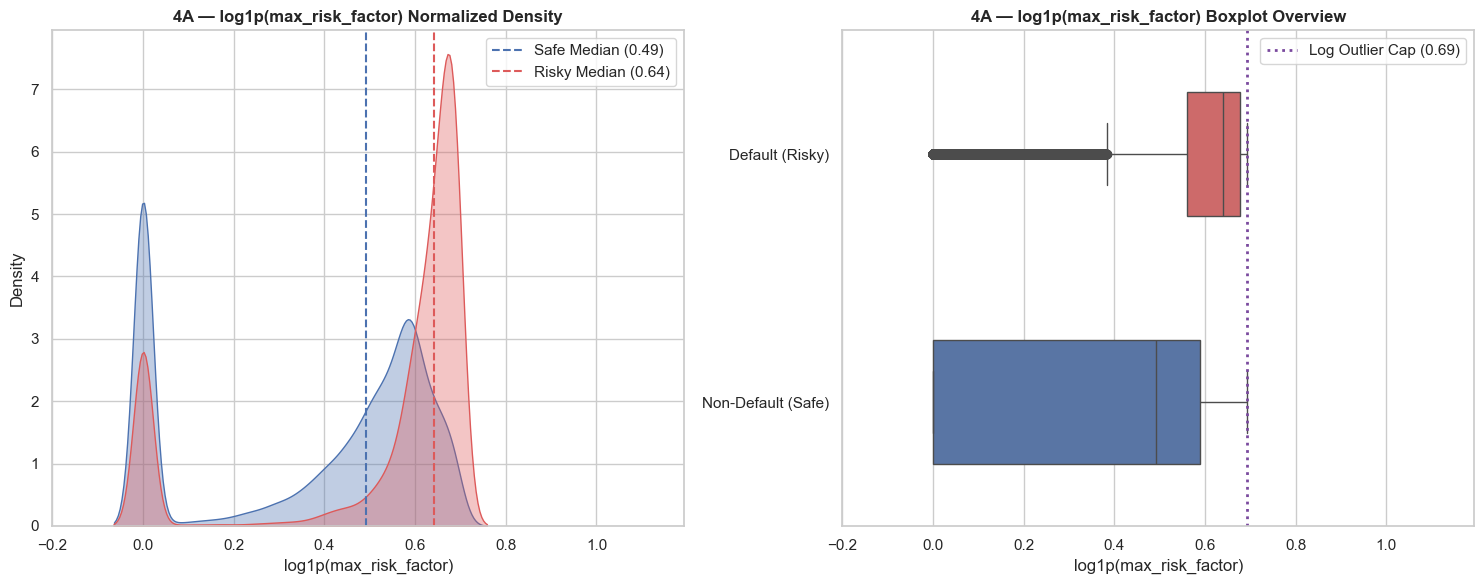

Risk cliff detected at bin: 0.8-0.9, PD jump: +23.40%
Risk cliff detected at bin: 0.9-1.0, PD jump: +29.92%


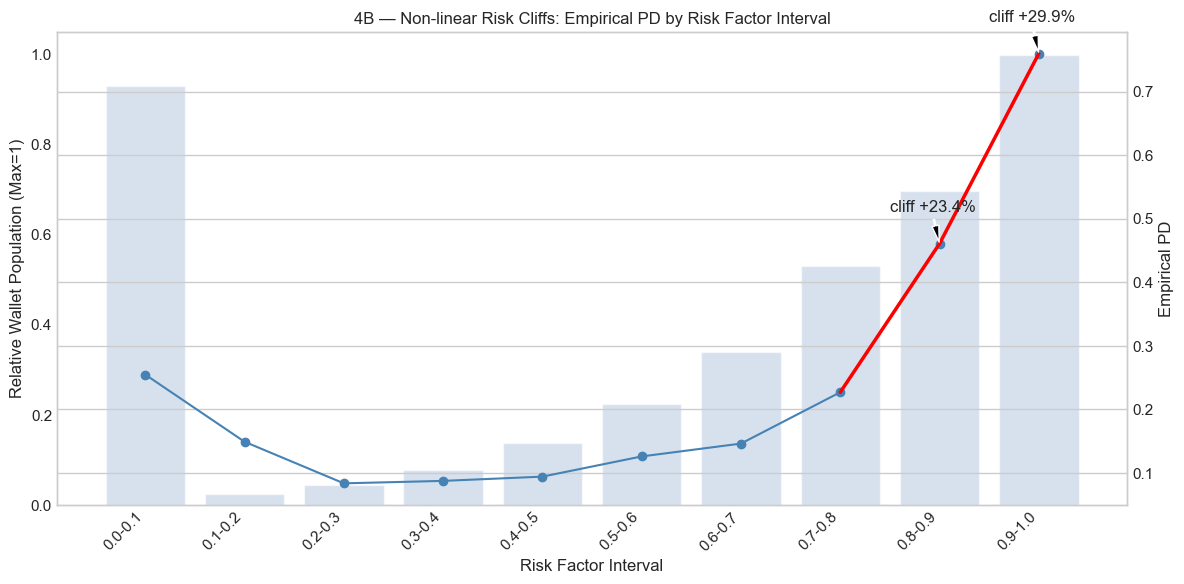

Liquidation Bucket Summary:
liq_bucket  wallet_count  default_rate
 0 (Never)        345453      0.322545
         1         21447      0.664102
         2          9376      0.733468
         3          5077      0.794958
        4+         21401      0.879492


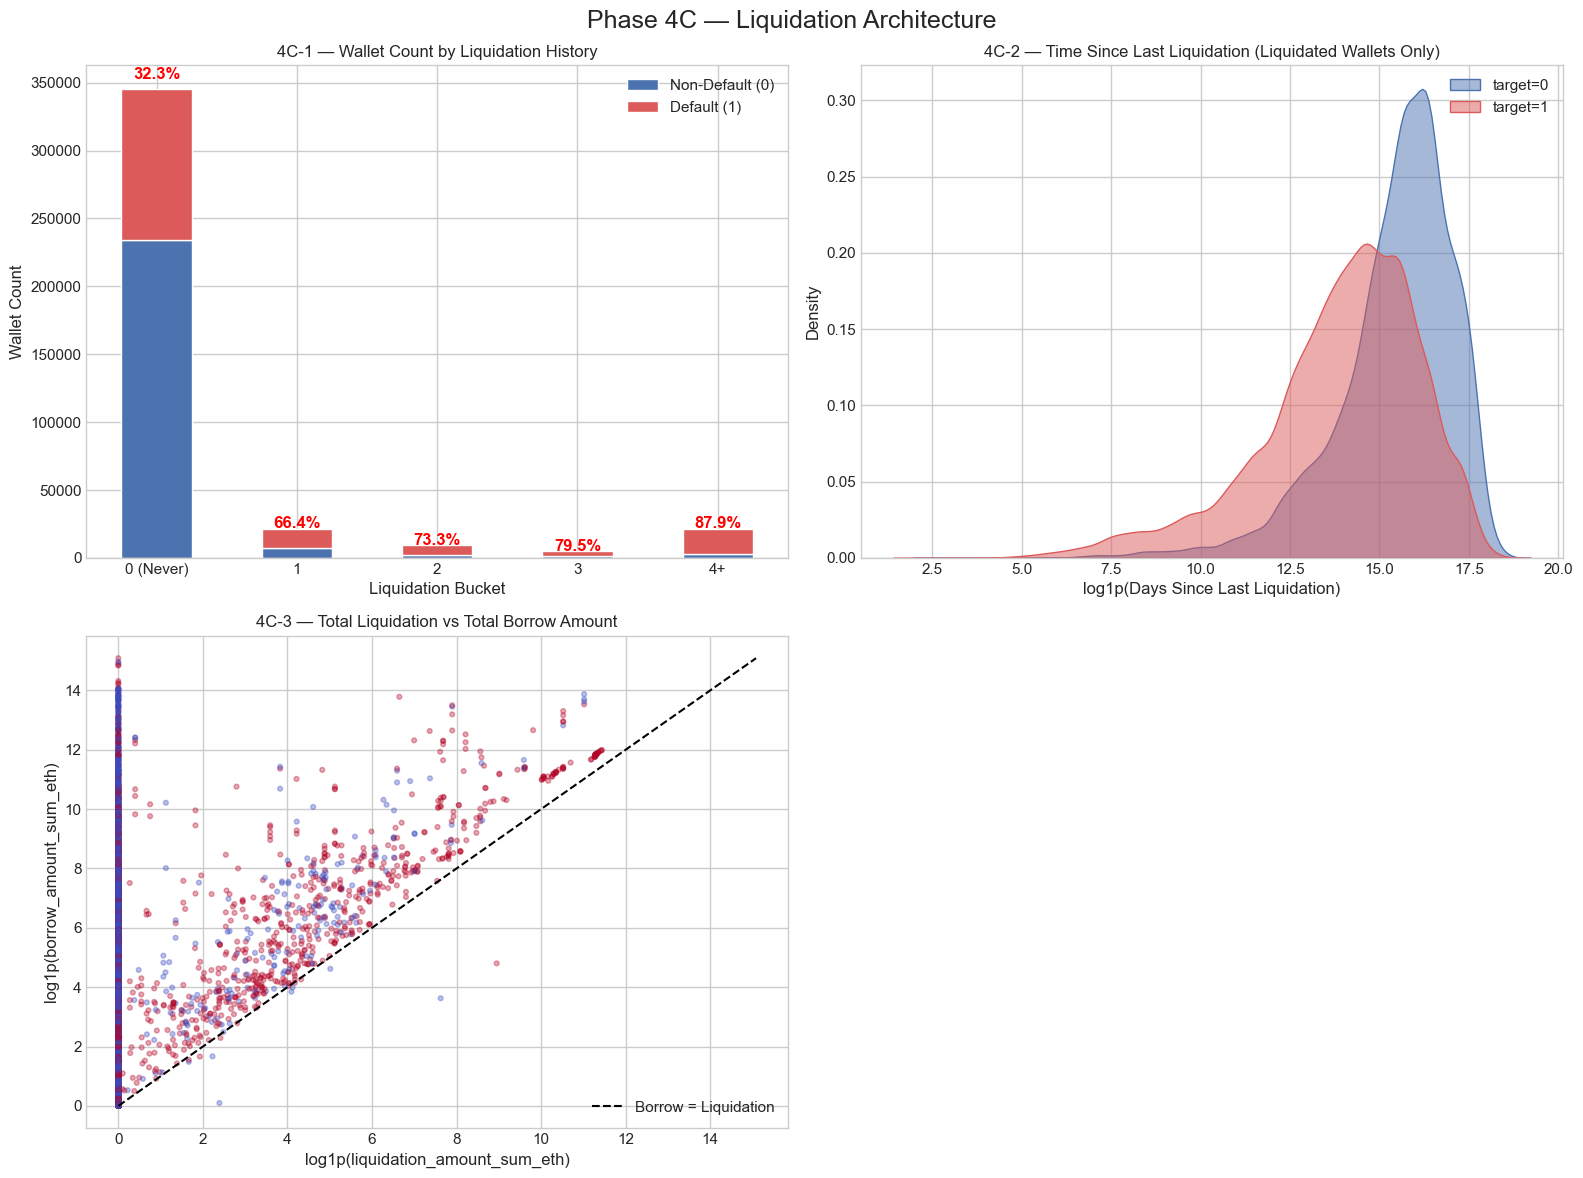

Borrow/Repay Discipline Summary:
   repay_bucket  wallet_count  default_rate
Severe Underpay        172884      0.360670
      High Risk         54533      0.476831
       Moderate         70033      0.437879
      Near Full         76877      0.369916
Overpay / Early         28427      0.279347


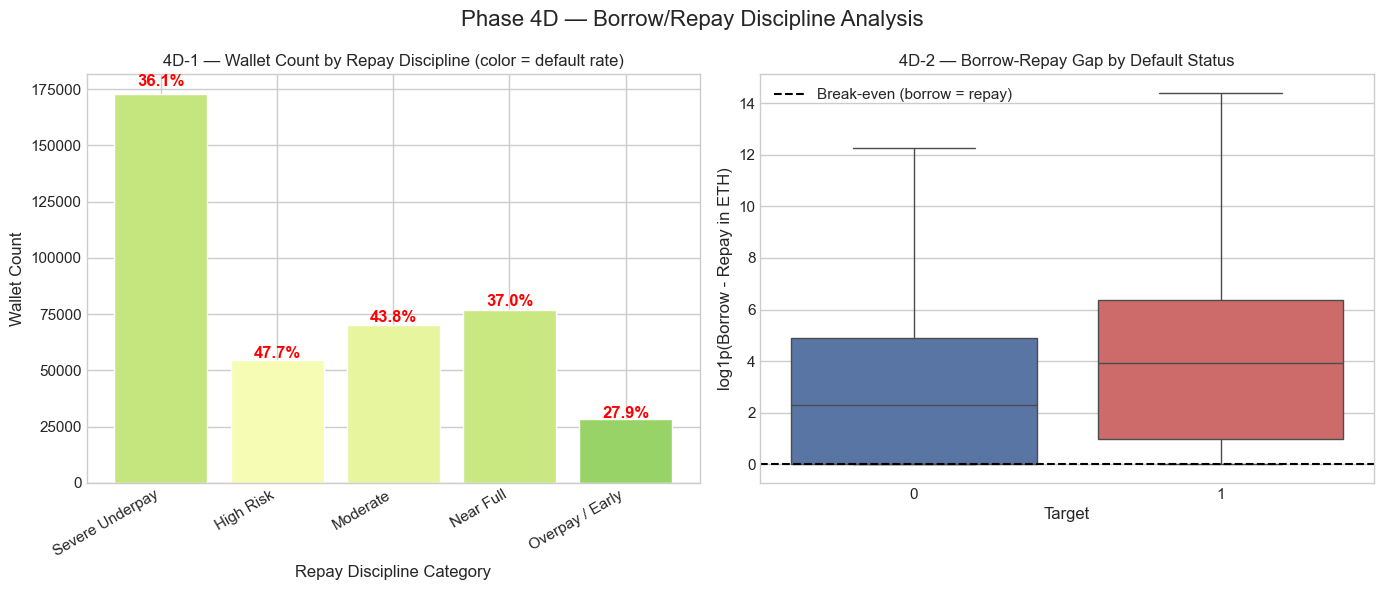

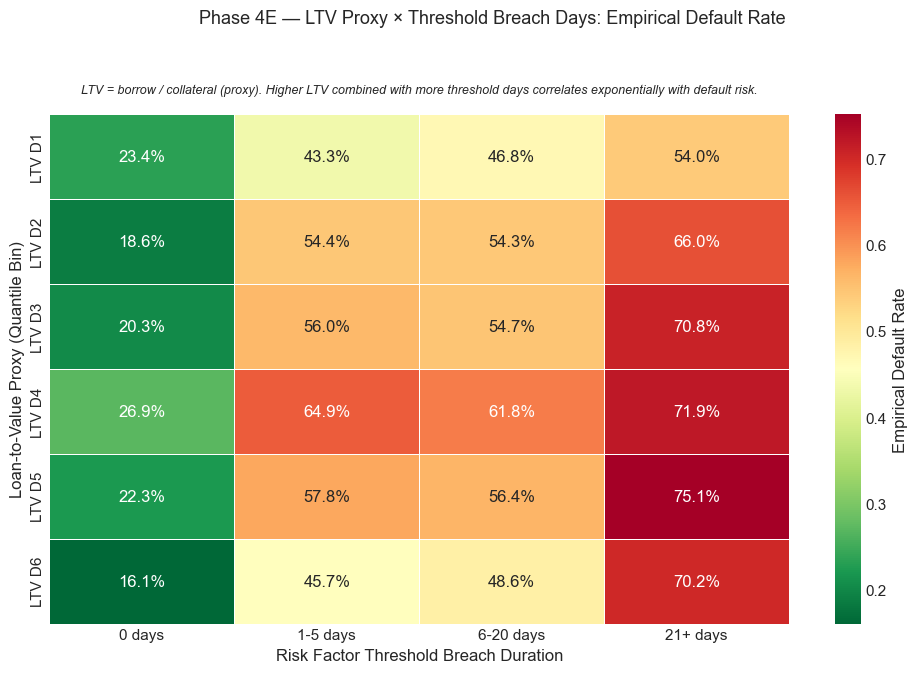

In [19]:
train_lf = audit_max_risk_factor_tail(train_lf)
detect_risk_cliffs(train_lf)
plot_liquidation_deep_dive(train_lf)
plot_borrow_repay_discipline(train_lf)
plot_collateral_utilization_heatmap(train_lf)

### Phase 5: Macro & Market Regime Context

### 5A: Market Regime Comparison

In [20]:
def plot_market_regime_comparison(df: pl.LazyFrame,
                                   split_ts: int = 1_672_531_200,
                                   save_dir: str = "reports/figures") -> None:
    try:
        import numpy as np
        import pandas as pd
        import matplotlib.pyplot as plt
        import matplotlib.ticker as mtick
        
        df_filtered = df.filter(pl.col("borrow_timestamp").is_not_null())
        
        df_filtered = df_filtered.with_columns([
            pl.when(pl.col("borrow_timestamp") < split_ts)
              .then(pl.lit("Bull Market"))
              .otherwise(pl.lit("Crypto Winter"))
              .alias("regime"),
            pl.from_epoch("borrow_timestamp", time_unit="s").dt.strftime("%Y-%m").alias("borrow_month")
        ])
        
        train_df = df_filtered.filter(pl.col("borrow_timestamp") < split_ts)
        test_df = df_filtered.filter(pl.col("borrow_timestamp") >= split_ts)
        
        train_size = train_df.select(pl.len()).collect().item()
        train_pd = train_df.select(pl.col("target").mean()).collect().item() * 100 if train_size > 0 else 0.0
        
        test_size = test_df.select(pl.len()).collect().item()
        test_pd = test_df.select(pl.col("target").mean()).collect().item() * 100 if test_size > 0 else 0.0
        
        regime_delta = test_pd - train_pd
        
        print(f"Train size: {train_size} | PD: {train_pd:.2f}% | Test size: {test_size} | PD: {test_pd:.2f}% | Regime PD delta: {regime_delta:+.2f}%")
        
        agg_df = df_filtered.group_by("borrow_month").agg([
            pl.len().alias("wallet_count"),
            pl.col("target").mean().alias("default_rate"),
            pl.col("regime").first().alias("regime")
        ]).sort("borrow_month").collect().to_pandas()
        
        agg_df["rolling_3m_default_rate"] = agg_df["default_rate"].rolling(3, min_periods=1).mean()
        
        plt.style.use("seaborn-v0_8-whitegrid")
        fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
        fig.suptitle("Phase 5A — Temporal Regime: Bull Market vs Crypto Winter", fontsize=16)
        
        ax1, ax2 = axes
        
        x_vals = np.arange(len(agg_df))
        months = agg_df["borrow_month"].values
        
        is_bull = agg_df["regime"] == "Bull Market"
        is_winter = agg_df["regime"] == "Crypto Winter"
        
        ax1.plot(x_vals, agg_df["wallet_count"], color="gray", alpha=0)
        
        ax1.fill_between(x_vals, 0, agg_df["wallet_count"], where=is_bull, color="green", alpha=0.5, label="Bull Market")
        ax1.fill_between(x_vals, 0, agg_df["wallet_count"], where=is_winter, color="red", alpha=0.4, label="Crypto Winter")
        
        winter_indices = np.where(is_winter)[0]
        split_idx = winter_indices[0] if len(winter_indices) > 0 else None
        
        if split_idx is not None:
            ax1.axvline(split_idx, color="black", linestyle="--")
            ax1.annotate("Train | Test", xy=(split_idx, ax1.get_ylim()[1]*0.9), 
                         xytext=(5, 0), textcoords="offset points", fontweight='bold')
                         
        ax1.set_ylabel("Monthly Borrow Volume")
        ax1.set_title("5A-1 — Monthly Wallet Borrow Activity")
        ax1.legend(loc="upper left")
        
        ax2.plot(x_vals, agg_df["rolling_3m_default_rate"], color="gray", alpha=0)
        
        if split_idx is not None:
            ax2.plot(x_vals[:split_idx+1], agg_df["rolling_3m_default_rate"][:split_idx+1], color="green", linewidth=2)
            ax2.plot(x_vals[split_idx:], agg_df["rolling_3m_default_rate"][split_idx:], color="red", linewidth=2)
            
            ax2.fill_between(x_vals[:split_idx+1], 0, agg_df["rolling_3m_default_rate"][:split_idx+1], color="green", alpha=0.25)
            ax2.fill_between(x_vals[split_idx:], 0, agg_df["rolling_3m_default_rate"][split_idx:], color="red", alpha=0.25)
            
            winter_df = agg_df.iloc[split_idx:]
            peak_idx = winter_df["rolling_3m_default_rate"].idxmax()
            if pd.notna(peak_idx):
                peak_val = winter_df.loc[peak_idx, "rolling_3m_default_rate"]
                ax2.annotate("Peak Default Spike", 
                             xy=(peak_idx, peak_val),
                             xytext=(peak_idx, peak_val*1.15),
                             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
                             ha='center', fontweight='bold', color='darkred')
        else:
            ax2.plot(x_vals, agg_df["rolling_3m_default_rate"], color="green" if is_bull.all() else "red", linewidth=2)
            ax2.fill_between(x_vals, 0, agg_df["rolling_3m_default_rate"], color="green" if is_bull.all() else "red", alpha=0.25)
            
        ax2.set_ylabel("Rolling 3M Default Rate")
        ax2.set_title("5A-2 — Rolling Default Rate")
        ax2.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
        
        ax2.set_xticks(x_vals)
        ax2.set_xticklabels(months, rotation=45, ha="right")
        
        # Show every N-th label to prevent crowding if there are many months
        n = max(1, len(x_vals) // 15)
        for i, label in enumerate(ax2.xaxis.get_ticklabels()):
            if i % n != 0:
                label.set_visible(False)
        
        plt.tight_layout()
        plt.savefig(f"{save_dir}/phase5a_market_regime_comparison.png", dpi=150)
        plt.show()
        plt.close(fig)
    except Exception as e:
        print(f"Error: {e}")

### 5B: Market Technical Indicator Correlation Analysis

In [21]:
def plot_market_indicator_correlations(df: pl.LazyFrame,
                                        save_dir: str = "reports/figures") -> None:
    try:
        import numpy as np
        import pandas as pd
        import matplotlib.pyplot as plt
        import seaborn as sns
        from scipy.stats import spearmanr
        
        expected_cols = [
            "market_adx", "market_adxr", "market_apo", "market_aroonosc", "market_aroonup",
            "market_atr", "market_cci", "market_cmo", "market_correl", "market_dx",
            "market_fastk", "market_fastd", "market_ht_trendmode", "market_linearreg_slope",
            "market_macd_macdext", "market_macd_macdfix", "market_macd",
            "market_macdsignal_macdext", "market_macdsignal_macdfix", "market_macdsignal",
            "market_max_drawdown_365d", "market_natr", "market_plus_di", "market_plus_dm",
            "market_ppo", "market_rocp", "market_rocr"
        ]
        
        available_cols = [c for c in expected_cols if c in df.collect_schema().names()]
        missing_cols = set(expected_cols) - set(available_cols)
        if missing_cols:
            print(f"Warning: Missing columns {missing_cols}")
            
        if not available_cols:
            print("No market indicator columns found. Exiting.")
            return
            
        cols_to_select = available_cols + ["target"]
        df_pd = df.select(cols_to_select).collect().to_pandas()
        
        df_pd = df_pd.fillna(df_pd.median())
        
        correlations = {}
        target_vals = df_pd["target"].values
        for col in available_cols:
            rho, _ = spearmanr(df_pd[col].values, target_vals)
            correlations[col] = rho if not np.isnan(rho) else 0.0
            
        sorted_corr_abs = sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True)
        top_10 = [col for col, _ in sorted_corr_abs[:10]]
        
        print("Top 10 Market Indicators by Spearman ρ with target:")
        for col, rho in sorted_corr_abs[:10]:
            print(f"{col}: {rho:.4f}")
            
        top_10_corr = df_pd[top_10].corr(method="spearman")
        
        plt.style.use("seaborn-v0_8-whitegrid")
        fig, axes = plt.subplots(1, 2, figsize=(16, 7))
        fig.suptitle("Phase 5B — Market Indicator Correlation Analysis", fontsize=16)
        
        ax1, ax2 = axes
        
        corr_series = pd.Series(correlations).sort_values()
        colors = ["#1a9988" if val > 0 else "#e07070" for val in corr_series.values]
        
        ax1.barh(corr_series.index, corr_series.values, color=colors)
        ax1.axvline(0, color="black", linestyle="--")
        ax1.set_xlabel("Spearman ρ with target")
        ax1.set_ylabel("Market Indicator")
        ax1.set_title("5B-1 — Market Indicators vs Default: Spearman ρ")
        
        mask = np.triu(np.ones_like(top_10_corr, dtype=bool))
        sns.heatmap(top_10_corr, mask=mask, cmap="coolwarm", annot=True, fmt=".2f", vmin=-1, vmax=1, ax=ax2)
        ax2.set_title("5B-2 — Top 10 Market Indicators: Pairwise Spearman Correlation")
        
        plt.tight_layout()
        plt.savefig(f"{save_dir}/phase5b_market_indicator_correlations.png", dpi=150)
        plt.show()
        plt.close(fig)
    except Exception as e:
        print(f"Error: {e}")

### 5C: Drawdown & Momentum Regime Space Analysis

In [22]:
def plot_drawdown_momentum_regime(df: pl.LazyFrame,
                                   sample_n: int = 6000,
                                   save_dir: str = "reports/figures") -> None:
    try:
        import numpy as np
        import pandas as pd
        import matplotlib.pyplot as plt
        import seaborn as sns
        
        expected_cols = ["market_max_drawdown_365d", "market_macd", "market_cci",
                         "market_atr", "market_linearreg_slope"]
        
        missing_cols = [c for c in expected_cols if c not in df.collect_schema().names()]
        if missing_cols:
            print(f"Warning: Missing columns {missing_cols}. Plotting may fail for some panels.")
            
        available_cols = [c for c in expected_cols if c in df.collect_schema().names()]
        
        # Execute median calculations and null imputations in a single multi-threaded Polars pass
        if available_cols:
            df = df.with_columns([
                pl.col(c).fill_null(pl.col(c).median()) for c in available_cols
            ])
                
        cols = available_cols + ["target"]
        df_eager = df.select(cols).collect()
        sample_size = min(df_eager.height, sample_n)
        df_pd = df_eager.sample(n=sample_size, seed=42).to_pandas()
        
        plt.style.use("seaborn-v0_8-whitegrid")
        fig, axes = plt.subplots(2, 2, figsize=(14, 11))
        fig.suptitle("Phase 5C — Drawdown & Momentum Market Regimes", fontsize=16)
        
        ax1, ax2 = axes[0]
        ax3, ax4 = axes[1]
        
        if "market_max_drawdown_365d" in available_cols:
            sns.kdeplot(data=df_pd[df_pd["target"] == 0], x="market_max_drawdown_365d", fill=True, alpha=0.45, color="#1a9641", ax=ax1, label="Target 0")
            sns.kdeplot(data=df_pd[df_pd["target"] == 1], x="market_max_drawdown_365d", fill=True, alpha=0.45, color="#d7191c", ax=ax1, label="Target 1")
            ax1.set_title("5C-1 — 365-Day Max Drawdown by Default Status")
            ax1.legend()
            
        if "market_macd" in available_cols and "market_cci" in available_cols:
            ax2.scatter(df_pd["market_macd"], df_pd["market_cci"], c=df_pd["target"], cmap="coolwarm", alpha=0.35, s=10)
            ax2.axhline(y=0, color="gray", linestyle="--", linewidth=0.8)
            ax2.axvline(x=0, color="gray", linestyle="--", linewidth=0.8)
            
            xlim = ax2.get_xlim()
            ylim = ax2.get_ylim()
            
            ax2.text(xlim[1]*0.5, ylim[1]*0.5, "Bullish + Overbought", style="italic", ha="center", va="center", alpha=0.7)
            ax2.text(xlim[0]*0.5, ylim[1]*0.5, "Bearish + Overbought", style="italic", ha="center", va="center", alpha=0.7)
            ax2.text(xlim[0]*0.5, ylim[0]*0.5, "Bearish + Oversold", style="italic", ha="center", va="center", alpha=0.7)
            ax2.text(xlim[1]*0.5, ylim[0]*0.5, "Bullish + Oversold", style="italic", ha="center", va="center", alpha=0.7)
            
            ax2.set_xlabel("market_macd")
            ax2.set_ylabel("market_cci")
            ax2.set_title("5C-2 — MACD × CCI Momentum Space")
            
        if "market_atr" in available_cols:
            sns.boxplot(data=df_pd, x="target", y="market_atr", hue="target", palette={0:"#4C72B0", 1:"#DD5A5A"}, ax=ax3, showfliers=False, orient="v", legend=False)
            ax3.set_title("5C-3 — Market Volatility (ATR) by Default Status")
            ax3.set_xlabel("Target")
            
        if "market_linearreg_slope" in available_cols:
            sns.violinplot(data=df_pd, x="target", y="market_linearreg_slope", hue="target", palette={0:"#4C72B0", 1:"#DD5A5A"}, inner="quartile", ax=ax4, legend=False)
            ax4.axhline(y=0, color="black", linestyle="--", label="Flat Trend")
            ax4.set_title("5C-4 — Price Trend Slope by Default Status")
            ax4.set_xlabel("Target")
            ax4.legend()
            
        plt.tight_layout()
        plt.savefig(f"{save_dir}/phase5c_drawdown_momentum_regime.png", dpi=150)
        plt.show()
        plt.close(fig)
    except Exception as e:
        print(f"Error in plot_drawdown_momentum_regime: {e}")
        plt.close("all")

Train size: 402754 | PD: 38.58% | Test size: 40207 | PD: 26.86% | Regime PD delta: -11.73%


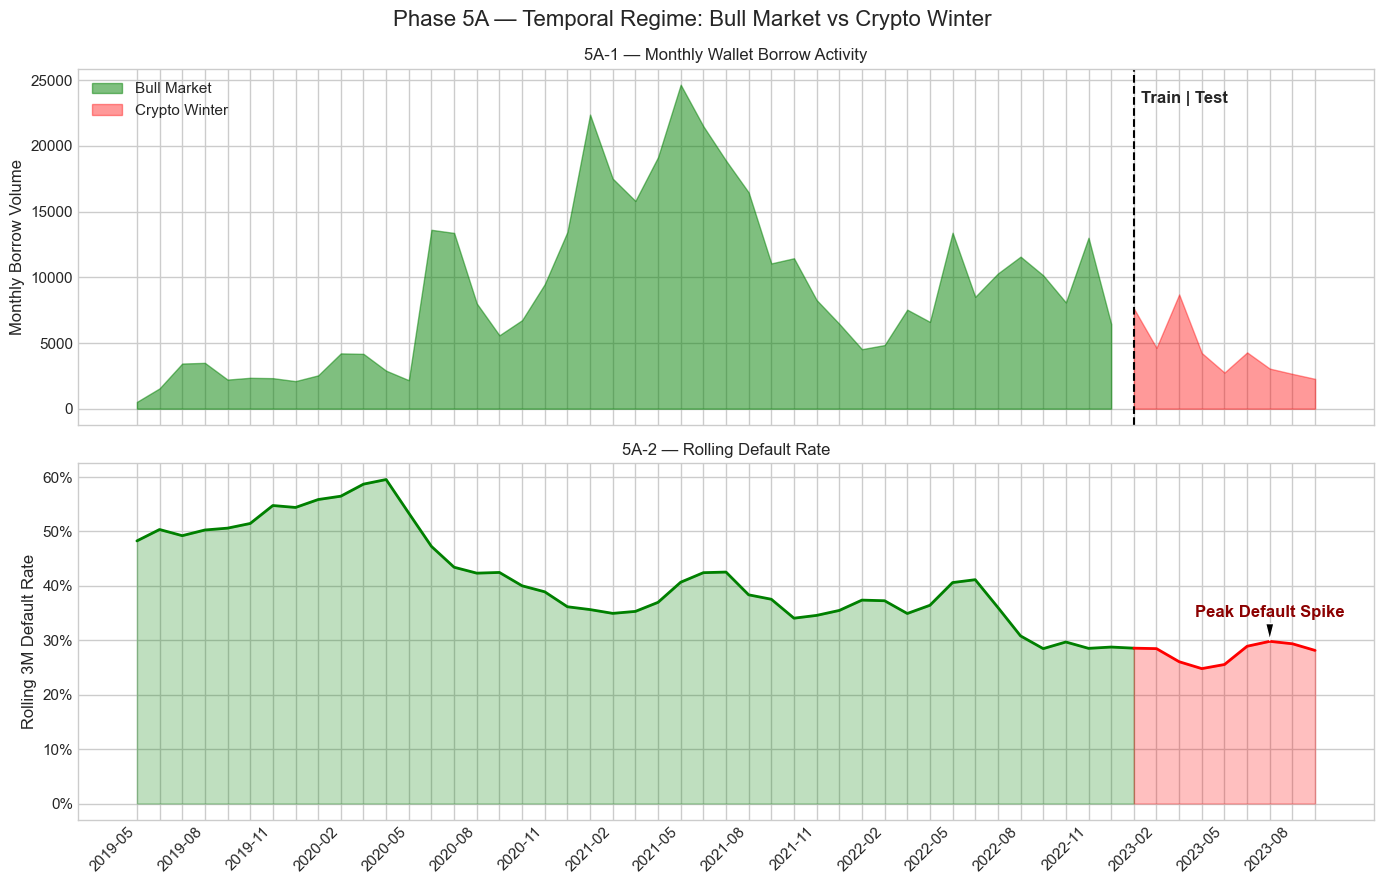

Top 10 Market Indicators by Spearman ρ with target:
market_atr: -0.0451
market_natr: -0.0422
market_max_drawdown_365d: 0.0345
market_plus_dm: -0.0269
market_aroonosc: 0.0202
market_dx: 0.0153
market_adx: 0.0142
market_apo: -0.0091
market_macd_macdext: -0.0091
market_adxr: 0.0089


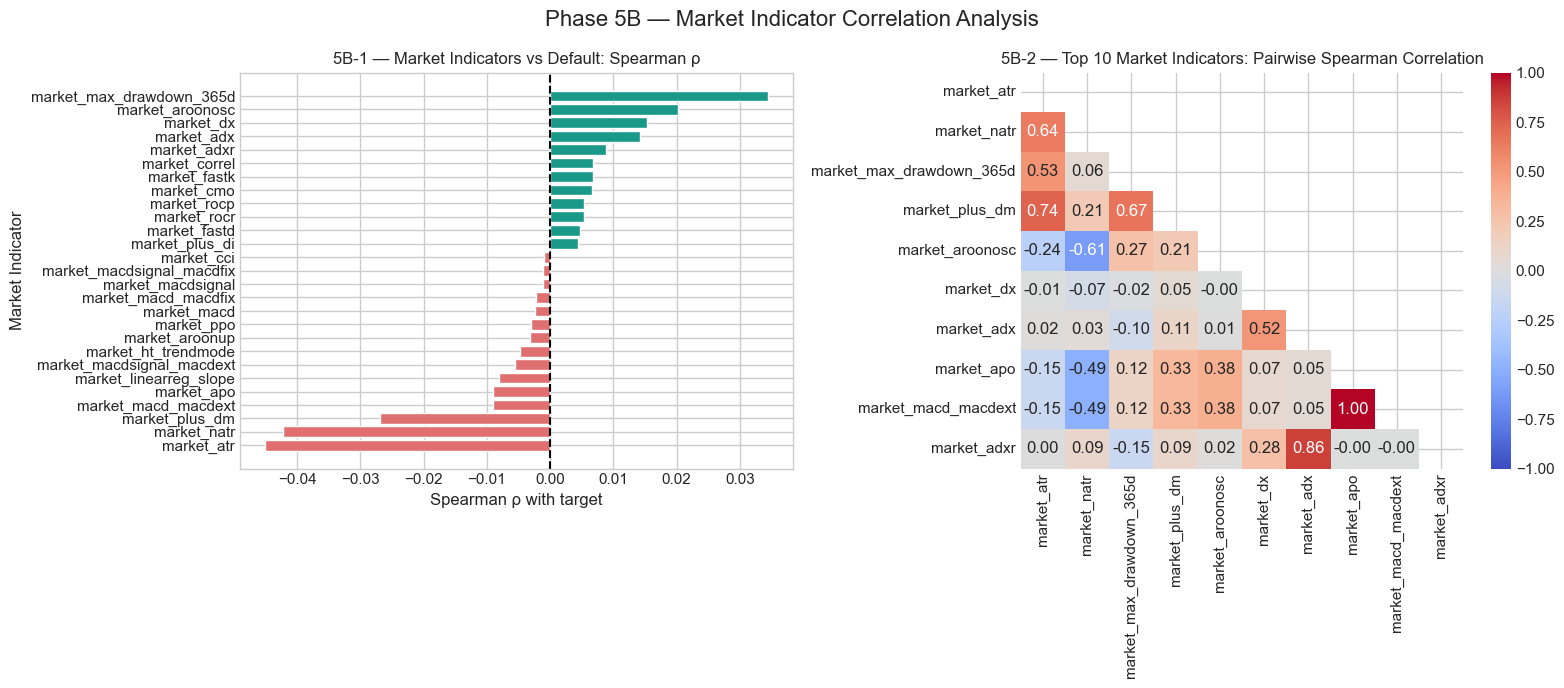

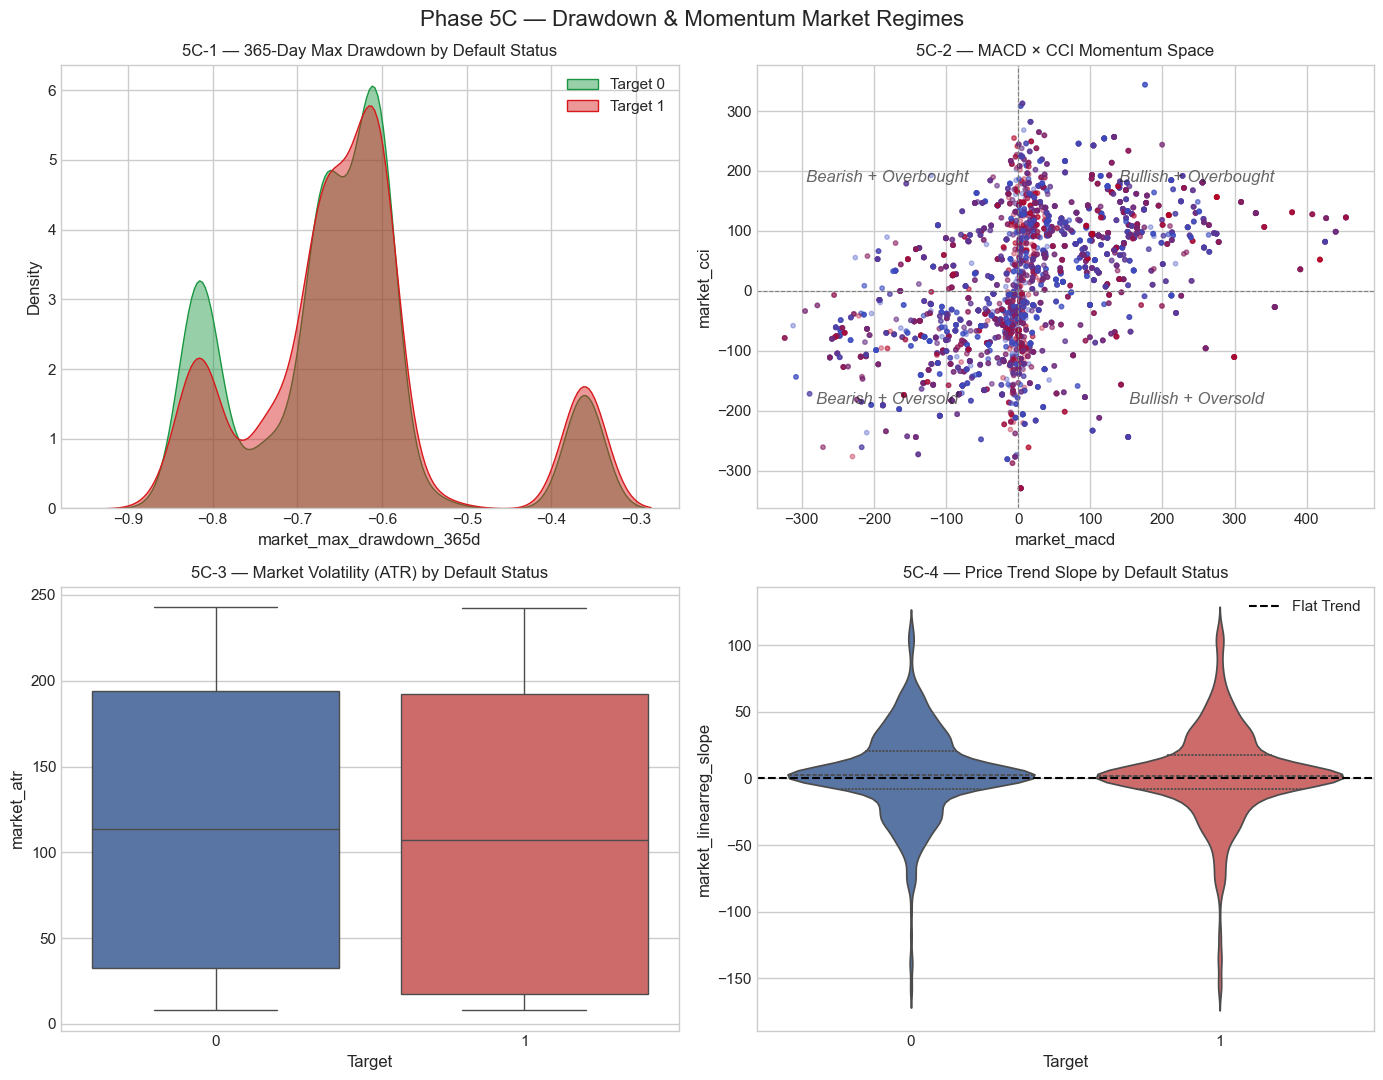

In [23]:
plot_market_regime_comparison(df_pruned)
plot_market_indicator_correlations(train_lf)
plot_drawdown_momentum_regime(train_lf)

In [24]:
from pathlib import Path
import polars as pl
Path("data/processed").mkdir(parents=True, exist_ok=True)

train_lf.sink_parquet("data/processed/train_raw_clean.parquet")
test_lf.sink_parquet("data/processed/test_raw_clean.parquet")
print("Exported train and test sets successfully.")

# Cold verification assertion check
train_check = pl.read_parquet("data/processed/train_raw_clean.parquet")
test_check = pl.read_parquet("data/processed/test_raw_clean.parquet")
print(f"[Verified] Train Shape: {train_check.shape} | Test Shape: {test_check.shape}")
assert train_check.shape[0] > 0 and test_check.shape[0] > 0, "Data Contract Corruption: Zero-byte files detected."


Exported train and test sets successfully.
[Verified] Train Shape: (402754, 78) | Test Shape: (40207, 78)
